In [1]:
#block 1
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
!pip install segmentation-models-pytorch
!pip install pydrive2

/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Dataset anemia.docx
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/Italy.xlsx
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/7/007_palpebral.png
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/7/7.jpg
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/7/007_forniceal.png
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/7/007_forniceal_palpebral.png
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/47/T_16_20190608_075548_forniceal.png
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/47/T_16_20190608_075548_palpebral.png
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/47/T_16_20190608_075548.jpg
/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/data

In [2]:
#block 2
import os
import glob
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configure GPU/CPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Seed everything for strict reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Environment seeded successfully.")


Using device: cuda
Environment seeded successfully.


In [3]:
# Block 3: Targeted Dataset Mapping (Input: Combined Mask, Target: Palpebral Mask)
DATASET_PATH = "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/"
countries = ['India', 'Italy']

data_records = []

for country in countries:
    country_path = os.path.join(DATASET_PATH, country)
    if not os.path.exists(country_path):
        continue
    
    patient_folders = [f for f in os.listdir(country_path) if os.path.isdir(os.path.join(country_path, f))]
    print(f"Country: {country} | Total Patients: {len(patient_folders)}")
    
    for patient in patient_folders:
        patient_path = os.path.join(country_path, patient)
        all_files = os.listdir(patient_path)
        
        # 1. Gather all files to find the Phase 1 output (Combined Mask)
        for file in all_files:
            if file.endswith('_forniceal_palpebral.png'):
                base_name = file.replace('_forniceal_palpebral.png', '')
                
                # 2. Formulate the explicit corresponding ground-truth target mask name
                expected_target_name = f"{base_name}_palpebral.png"
                
                # Verify that the target exists
                if expected_target_name in all_files:
                    input_mask_path = os.path.join(patient_path, file)
                    target_mask_path = os.path.join(patient_path, expected_target_name)
                    
                    data_records.append({
                        'patient_id': f"{country}_{patient}",
                        'country': country,
                        'image_path': input_mask_path,  # This is now the Combined Mask!
                        'mask_path': target_mask_path   # This is the Palpebral Mask
                    })

df_data = pd.DataFrame(data_records)
print(f"\nTotal strictly matched mask-to-mask records found: {len(df_data)}")


Country: India | Total Patients: 95
Country: Italy | Total Patients: 123

Total strictly matched mask-to-mask records found: 209


--------------------------------------------------
Patient ID: India_12
Input Image (Forniceal+Palpebral): 20200203_103722_forniceal_palpebral.png
Target Mask (Palpebral):  20200203_103722_palpebral.png
--------------------------------------------------


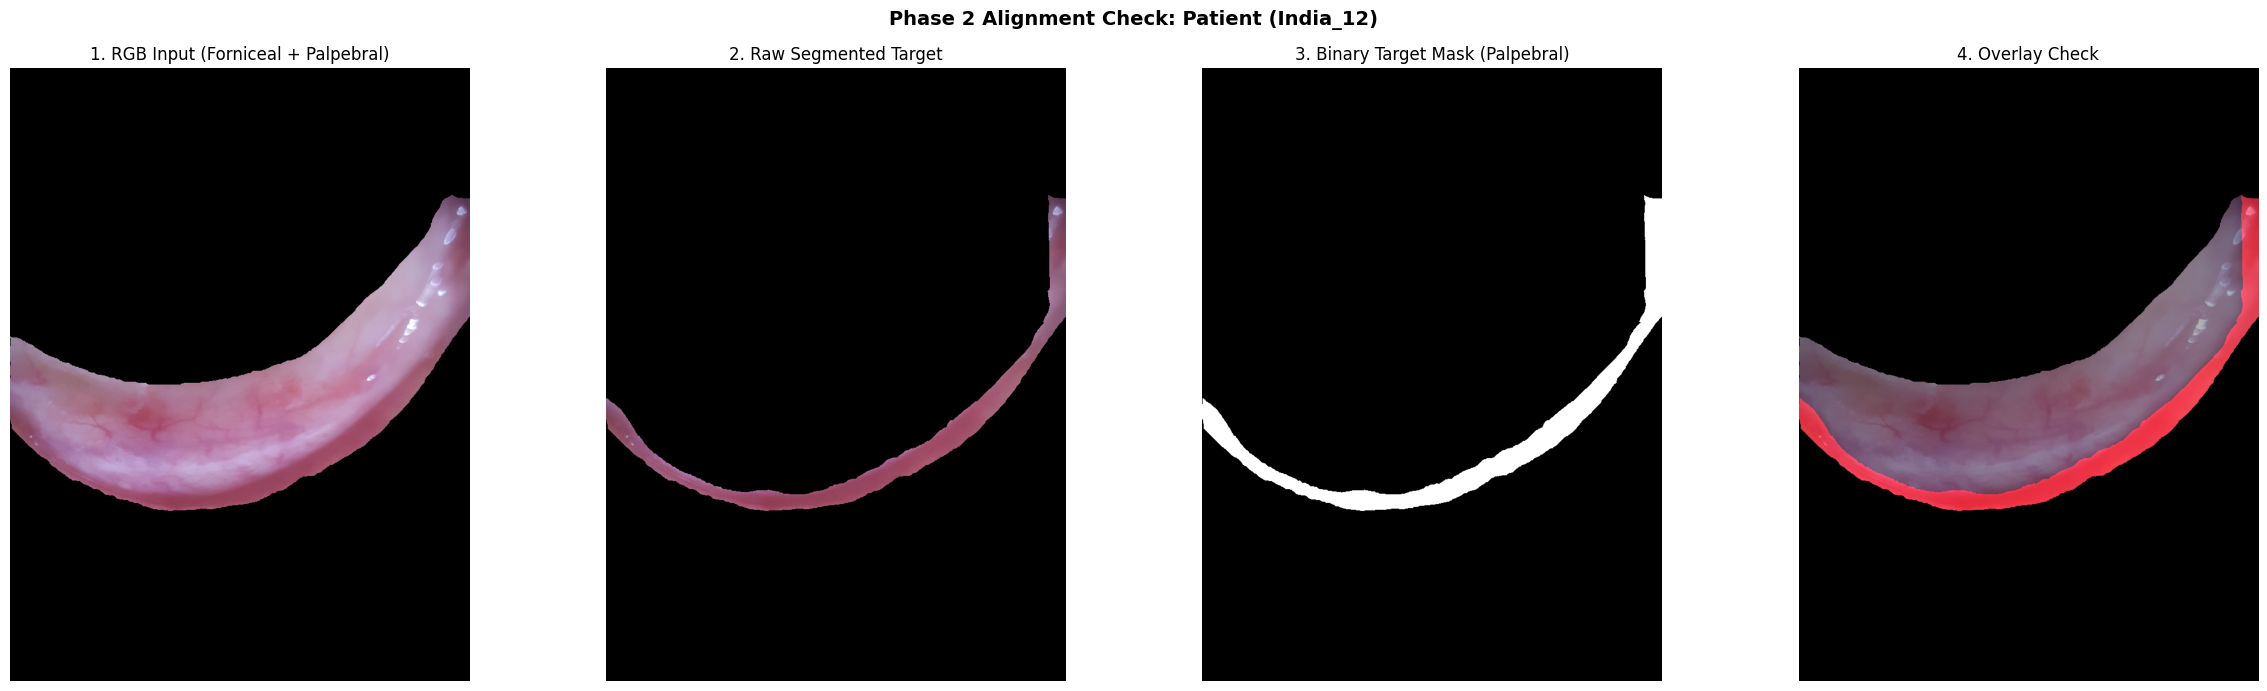

In [4]:
# Block 4: Alignment Check (RGB Input -> Binary Target)
if len(df_data) > 0:
    sample_row = df_data.sample(n=1).iloc[0]
    
    image_filename = os.path.basename(sample_row['image_path'])
    mask_filename = os.path.basename(sample_row['mask_path'])
    
    print("-" * 50)
    print(f"Patient ID: {sample_row['patient_id']}")
    print(f"Input Image (Forniceal+Palpebral): {image_filename}")
    print(f"Target Mask (Palpebral):  {mask_filename}")
    print("-" * 50)
    
    # 1. Load INPUT as RGB and APPLY the Alpha Channel to black out the background
    input_raw = cv2.imread(sample_row['image_path'], cv2.IMREAD_UNCHANGED)
    if input_raw is not None and input_raw.shape[-1] == 4:
        input_alpha = (input_raw[:, :, 3] > 10).astype(np.uint8)
        input_rgb_full = cv2.cvtColor(input_raw[:, :, :3], cv2.COLOR_BGR2RGB)
        orig_rgb = cv2.bitwise_and(input_rgb_full, input_rgb_full, mask=input_alpha)
    else:
        orig_rgb = cv2.cvtColor(input_raw, cv2.COLOR_BGR2RGB)
    
    # 2. Load TARGET as Binary Mask (palpebral.png)
    mask_raw = cv2.imread(sample_row['mask_path'], cv2.IMREAD_UNCHANGED)
    if mask_raw is not None and mask_raw.shape[-1] == 4:
        target_alpha = (mask_raw[:, :, 3] > 10).astype(np.uint8) * 255
        binary_mask = target_alpha
        mask_rgb = cv2.cvtColor(mask_raw[:, :, :3], cv2.COLOR_BGR2RGB)
    else:
        mask_rgb = cv2.cvtColor(mask_raw, cv2.COLOR_BGR2RGB)
        binary_mask = np.any(mask_rgb > 10, axis=-1).astype(np.uint8) * 255
    
    if orig_rgb.shape[:2] != binary_mask.shape:
        binary_mask_resized = cv2.resize(binary_mask, (orig_rgb.shape[1], orig_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_rgb_resized = cv2.resize(mask_rgb, (orig_rgb.shape[1], orig_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        binary_mask_resized = binary_mask
        mask_rgb_resized = mask_rgb
        
    red_mask = np.zeros_like(orig_rgb)
    red_mask[:, :, 0] = binary_mask_resized  
    
    overlay = cv2.addWeighted(orig_rgb, 0.7, red_mask, 0.5, 0)
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 7))
    plt.suptitle(f"Phase 2 Alignment Check: Patient ({sample_row['patient_id']})", fontsize=14, weight='bold')
    
    axes[0].imshow(orig_rgb)
    axes[0].set_title('1. RGB Input (Forniceal + Palpebral)')
    axes[0].axis('off')
    
    axes[1].imshow(mask_rgb_resized)
    axes[1].set_title('2. Raw Segmented Target')
    axes[1].axis('off')
    
    axes[2].imshow(binary_mask_resized, cmap='gray')
    axes[2].set_title('3. Binary Target Mask (Palpebral)')
    axes[2].axis('off')
    
    axes[3].imshow(overlay)
    axes[3].set_title('4. Overlay Check')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: No data found in df_data.")

In [5]:
# block 5
from sklearn.model_selection import StratifiedKFold, train_test_split

unique_patients = df_data[['patient_id', 'country']].drop_duplicates().reset_index(drop=True)

# 1. Isolate 15% Strict Holdout Test Set for final evaluation
train_val_patients, test_patients = train_test_split(
    unique_patients, test_size=0.15, random_state=42, stratify=unique_patients['country']
)
test_ids = set(test_patients['patient_id'])
df_test = df_data[df_data['patient_id'].isin(test_ids)].reset_index(drop=True)

# 2. Setup 3-Fold Cross Validation on the remaining 85%
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_folds = []
train_val_patients = train_val_patients.reset_index(drop=True)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_patients, train_val_patients['country'])):
    fold_train_ids = set(train_val_patients.iloc[train_idx]['patient_id'])
    fold_val_ids = set(train_val_patients.iloc[val_idx]['patient_id'])
    
    df_train_fold = df_data[df_data['patient_id'].isin(fold_train_ids)].reset_index(drop=True)
    df_val_fold = df_data[df_data['patient_id'].isin(fold_val_ids)].reset_index(drop=True)
    
    cv_folds.append((df_train_fold, df_val_fold))

print("--- Patient-Level K-Fold Split Summary ---")
print(f"Total Holdout Test Samples: {len(df_test)} (Patients: {len(test_ids)})")
for i, (tr, vl) in enumerate(cv_folds):
    print(f"Fold {i+1} - Train: {len(tr)} samples | Val: {len(vl)} samples")
    assert len(set(tr['patient_id']).intersection(set(vl['patient_id']))) == 0, f"Train/Val Leak in Fold {i+1}"
    assert len(set(tr['patient_id']).intersection(test_ids)) == 0, f"Test Leak in Fold {i+1}"

--- Patient-Level K-Fold Split Summary ---
Total Holdout Test Samples: 32 (Patients: 32)
Fold 1 - Train: 118 samples | Val: 59 samples
Fold 2 - Train: 118 samples | Val: 59 samples
Fold 3 - Train: 118 samples | Val: 59 samples


In [6]:
# Block 6: Phase 2 Dataset Loader (RGB Input -> Binary Target)
class AnemiaDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. Read INPUT as RGB and remove hidden background using alpha
        input_raw = cv2.imread(row['image_path'], cv2.IMREAD_UNCHANGED)
        if input_raw is not None and input_raw.shape[-1] == 4:
            input_alpha = (input_raw[:, :, 3] > 10).astype(np.uint8)
            input_rgb_full = cv2.cvtColor(input_raw[:, :, :3], cv2.COLOR_BGR2RGB)
            image = cv2.bitwise_and(input_rgb_full, input_rgb_full, mask=input_alpha)
        else:
            image = cv2.cvtColor(input_raw, cv2.COLOR_BGR2RGB)
        
        # 2. Read TARGET and convert strictly to Binary Mask
        mask_raw = cv2.imread(row['mask_path'], cv2.IMREAD_UNCHANGED)
        if mask_raw is not None and mask_raw.shape[-1] == 4:
            binary_mask = (mask_raw[:, :, 3] > 10).astype(np.uint8) * 255
        else:
            mask_rgb = cv2.cvtColor(mask_raw, cv2.COLOR_BGR2RGB)
            binary_mask = np.any(mask_rgb > 10, axis=-1).astype(np.uint8) * 255
        
        if image.shape[:2] != binary_mask.shape:
            binary_mask = cv2.resize(binary_mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        
        # Apply Transforms
        if self.transforms:
            augmented = self.transforms(image=image, mask=binary_mask)
            image = augmented['image']
            mask = augmented['mask']
            
        if isinstance(mask, torch.Tensor):
            mask = mask.float() / 255.0
        else:
            mask = torch.from_numpy(mask).float() / 255.0
            
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)
            
        return image, mask

In [7]:
# block 8
train_transforms = A.Compose([
    A.Resize(256, 256),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5, border_mode=cv2.BORDER_CONSTANT, fill_value=0),
    A.RandomBrightnessContrast(p=0.5), 
    A.RandomGamma(p=0.3),              
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()], is_check_shapes=False)

val_test_transforms = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()], is_check_shapes=False)

# Train and Val DataLoaders will be created inside the loop per fold
test_dataset = AnemiaDataset(df_test, transforms=val_test_transforms)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

/tmp/ipykernel_23/3965329591.py:5: UserWarning: Argument(s) 'fill_value' are not valid for transform Rotate
  A.Rotate(limit=30, p=0.5, border_mode=cv2.BORDER_CONSTANT, fill_value=0),


In [8]:
#block 9
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
        self.attention_weights = None

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        self.attention_weights = psi.detach()
        return x * psi

In [9]:
#block 10 
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class AttentionResUNet(nn.Module):
    def __init__(self, out_channels=1, pretrained=True):
        super(AttentionResUNet, self).__init__()
        
        # Using ResNet34 specifically
        weights = models.ResNet34_Weights.DEFAULT if pretrained else None
        resnet = models.resnet34(weights=weights)
        
        self.init_conv = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        
        self.att4 = AttentionGate(F_g=256, F_l=256, F_int=126)
        self.att3 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.att2 = AttentionGate(F_g=64,  F_l=64,  F_int=32)
        self.att1 = AttentionGate(F_g=64,  F_l=64,  F_int=32)
        
        self.dec_conv4 = DoubleConv(512, 256)
        self.dec_conv3 = DoubleConv(256, 128)
        self.dec_conv2 = DoubleConv(128, 64)
        self.dec_conv1 = DoubleConv(128, 64)
        
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x_init = self.init_conv(x)
        x_mp = self.maxpool(x_init)
        
        s1 = self.layer1(x_mp)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        s4 = self.layer4(s3)
        
        g4 = self.up4(s4)
        x_att4 = self.att4(g=g4, x=s3)
        d4 = torch.cat((g4, x_att4), dim=1)
        d4 = self.dec_conv4(d4)
        
        g3 = self.up3(d4)
        x_att3 = self.att3(g=g3, x=s2)
        d3 = torch.cat((g3, x_att3), dim=1)
        d3 = self.dec_conv3(d3)
        
        g2 = self.up2(d3)
        x_att2 = self.att2(g=g2, x=s1)
        d2 = torch.cat((g2, x_att2), dim=1)
        d2 = self.dec_conv2(d2)
        
        g1 = self.up1(d2)
        x_att1 = self.att1(g=g1, x=x_init)
        d1 = torch.cat((g1, x_att1), dim=1)
        d1 = self.dec_conv1(d1)
        
        out = self.final_up(d1)
        logits = self.final_conv(out)
        return logits

In [10]:
# block 10.1
import segmentation_models_pytorch as smp

class REBNCONV(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, dirate=1):
        super(REBNCONV, self).__init__()
        self.conv_s1 = nn.Conv2d(in_ch, out_ch, 3, padding=1*dirate, dilation=1*dirate)
        self.bn_s1 = nn.BatchNorm2d(out_ch)
        self.relu_s1 = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu_s1(self.bn_s1(self.conv_s1(x)))

def _upsample_like(src, tar):
    src = F.interpolate(src, size=tar.shape[2:], mode='bilinear', align_corners=True)
    return src

class RSU7(nn.Module):
    def __init__(self, in_ch=3, mid_ch=12, out_ch=3):
        super(RSU7, self).__init__()
        self.rebnconvin = REBNCONV(in_ch, out_ch, dirate=1)
        self.rebnconv1 = REBNCONV(out_ch, mid_ch, dirate=1)
        self.pool1 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        self.rebnconv2 = REBNCONV(mid_ch, mid_ch, dirate=1)
        self.pool2 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        self.rebnconv3 = REBNCONV(mid_ch, mid_ch, dirate=1)
        self.rebnconv4 = REBNCONV(mid_ch, out_ch, dirate=1)
    def forward(self, x):
        hx = self.rebnconvin(x)
        h1 = self.rebnconv1(hx)
        h = self.pool1(h1)
        h2 = self.rebnconv2(h)
        h = self.pool2(h2)
        h3 = self.rebnconv3(h)
        h4 = self.rebnconv4(h3)
        return hx + _upsample_like(h4, hx)

class U2Net_lite(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super(U2Net_lite, self).__init__()
        self.stage1 = RSU7(in_ch, 16, 64)
        self.stage2 = RSU7(64, 16, 64)
        self.pool12 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        self.stage3 = RSU7(64, 16, 64)
        self.side1 = nn.Conv2d(64, out_ch, 3, padding=1)
        self.side2 = nn.Conv2d(64, out_ch, 3, padding=1)
        self.outconv = nn.Conv2d(2, out_ch, 1)
    def forward(self, x):
        hx1 = self.stage1(x)
        hx = self.pool12(hx1)
        hx2 = self.stage2(hx)
        hx = self.pool12(hx2)
        hx3 = self.stage3(hx)
        d2 = hx2 + _upsample_like(hx3, hx2)
        d1 = hx1 + _upsample_like(d2, hx1)
        s1 = self.side1(d1)
        s2 = self.side2(d2)
        out = self.outconv(torch.cat((s1, _upsample_like(s2, s1)), 1))
        return out

def get_fresh_models():
    model_unet = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
    model_unetpp = smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
    model_u2net = U2Net_lite(in_ch=3, out_ch=1)
    return {
        'Attention_ResUNet': AttentionResUNet(out_channels=1, pretrained=True).to(device),
        'Simple_UNet': model_unet.to(device),
        'UNet_PlusPlus': model_unetpp.to(device),
        'U2_Net': model_u2net.to(device)
    }

models_dict = get_fresh_models()

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:02<00:00, 43.4MB/s]


In [11]:
# Block 11: Stabilized Loss Functions and Metrics
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0): # CHANGED: Increased smoothing for sparse targets
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1. - dice

class CombinedLoss(nn.Module):
    def __init__(self):
        super(CombinedLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth=1.0)

    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * self.dice(logits, targets)

def compute_metrics(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float().view(-1)
    targets_flat = targets.view(-1)
    
    tp = (preds * targets_flat).sum().item()
    fp = (preds * (1. - targets_flat)).sum().item()
    fn = ((1. - preds) * targets_flat).sum().item()
    
    smooth = 1.0 # CHANGED: Matched smoothing to loss function
    return {
        'dice': (2. * tp + smooth) / (2. * tp + fp + fn + smooth),
        'iou': (tp + smooth) / (tp + fp + fn + smooth),
        'precision': (tp + smooth) / (tp + fp + smooth),
        'recall': (tp + smooth) / (tp + fn + smooth)
    }

criterion = CombinedLoss()

In [12]:
# Block 12: Core Training Protocols with Gradient Clipping
class EarlyStopping:
    def __init__(self, patience=8, delta=0.001, path='best_model.pth'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    metrics_summary = {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0}
    
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        
        # --- NEW: GRADIENT CLIPPING ---
        # This stops the weights from exploding when encountering a tough batch
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        batch_metrics = compute_metrics(logits, masks)
        for k in metrics_summary: metrics_summary[k] += batch_metrics[k] * images.size(0)
            
    epoch_loss = running_loss / len(loader.dataset)
    for k in metrics_summary: metrics_summary[k] /= len(loader.dataset)
    return epoch_loss, metrics_summary

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    metrics_summary = {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0}
    
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, masks)
            
            running_loss += loss.item() * images.size(0)
            batch_metrics = compute_metrics(logits, masks)
            for k in metrics_summary: metrics_summary[k] += batch_metrics[k] * images.size(0)
                
    epoch_loss = running_loss / len(loader.dataset)
    for k in metrics_summary: metrics_summary[k] /= len(loader.dataset)
    return epoch_loss, metrics_summary

Starting Phase 2 K-Fold Training Loop...

Training Attention_ResUNet | FOLD 1/3


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

Epoch [1/200] | LR: 1.0e-05 | Train Loss: 0.6831 | Val Loss: 0.7392 | Val Dice: 0.2096


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

Epoch [2/200] | LR: 1.0e-05 | Train Loss: 0.6782 | Val Loss: 0.7391 | Val Dice: 0.2122


...

Epoch [26/200] | LR: 5.0e-04 | Train Loss: 0.0731 | Val Loss: 1.0507 | Val Dice: 0.0000


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

Epoch [27/200] | LR: 5.0e-04 | Train Loss: 0.1552 | Val Loss: 0.9424 | Val Dice: 0.0675


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

Epoch [28/200] | LR: 5.0e-04 | Train Loss: 0.0422 | Val Loss: 0.7894 | Val Dice: 0.2211
Early stopping triggered for U2_Net Fold 3 at epoch 28.


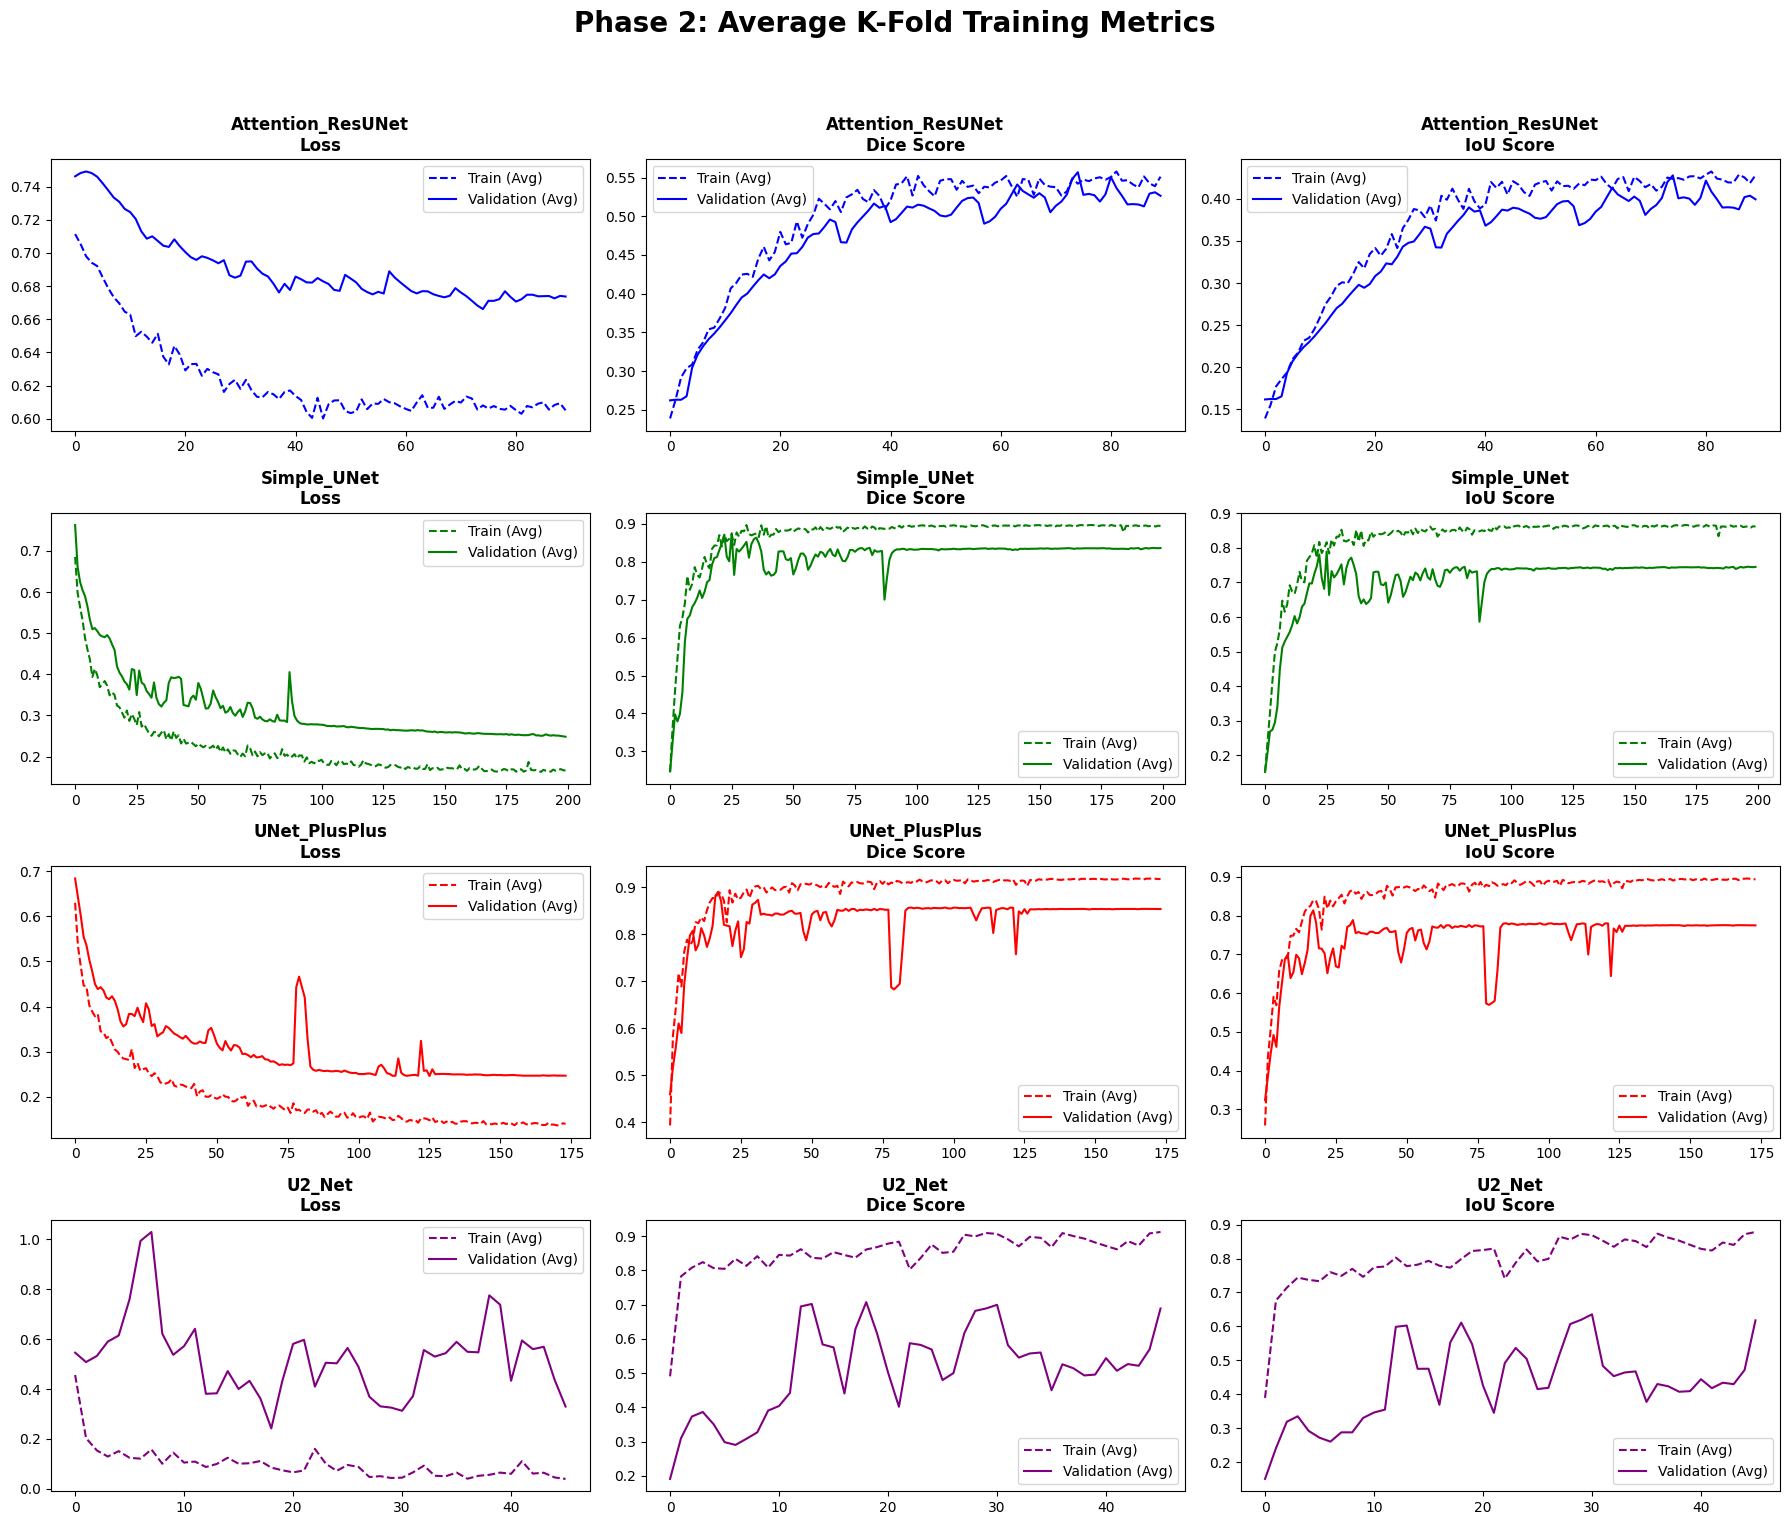

In [13]:
# block 13
EPOCHS = 200  
all_histories = {}
architecture_names = ['Attention_ResUNet', 'Simple_UNet', 'UNet_PlusPlus', 'U2_Net']

print("Starting Phase 2 K-Fold Training Loop...")

for model_name in architecture_names:
    all_histories[model_name] = []
    
    for fold, (df_train_fold, df_val_fold) in enumerate(cv_folds):
        print(f"\n{'='*50}\nTraining {model_name} | FOLD {fold+1}/{n_splits}\n{'='*50}")
        
        train_dataset = AnemiaDataset(df_train_fold, transforms=train_transforms)
        val_dataset = AnemiaDataset(df_val_fold, transforms=val_test_transforms)
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, drop_last=True)
        val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
        
        # Pull fresh weights for each fold
        current_model = get_fresh_models()[model_name]
        
        if model_name == 'U2_Net':
            optimizer = optim.AdamW(current_model.parameters(), lr=1e-3, weight_decay=1e-5)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)
        elif model_name == 'Attention_ResUNet':
            optimizer = optim.AdamW([
                {'params': current_model.init_conv.parameters(), 'lr': 1e-5},
                {'params': current_model.layer1.parameters(), 'lr': 1e-5},
                {'params': current_model.layer2.parameters(), 'lr': 1e-5},
                {'params': current_model.layer3.parameters(), 'lr': 1e-5},
                {'params': current_model.layer4.parameters(), 'lr': 1e-5},
                {'params': current_model.dec_conv4.parameters(), 'lr': 1e-5},
                {'params': current_model.dec_conv3.parameters(), 'lr': 1e-5},
                {'params': current_model.dec_conv2.parameters(), 'lr': 1e-5},
                {'params': current_model.dec_conv1.parameters(), 'lr': 1e-5},
                {'params': current_model.final_conv.parameters(), 'lr': 1e-5},
            ], weight_decay=1e-4) 
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6)
        else:
            optimizer = optim.AdamW(current_model.parameters(), lr=5e-5, weight_decay=1e-3)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6)
            
        early_stopping = EarlyStopping(patience=15, path=f'phase2_{model_name}_fold{fold}.pth') 
        history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [], 'train_iou': [], 'val_iou': []}

        for epoch in range(1, EPOCHS + 1):
            train_loss, train_met = train_one_epoch(current_model, train_loader, criterion, optimizer, device)
            val_loss, val_met = validate(current_model, val_loader, criterion, device)
            
            scheduler.step(val_loss) 
            
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['train_dice'].append(train_met['dice'])
            history['val_dice'].append(val_met['dice'])
            history['train_iou'].append(train_met['iou'])
            history['val_iou'].append(val_met['iou'])
            
            current_lr = optimizer.param_groups[-1]['lr']
            print(f"Epoch [{epoch}/{EPOCHS}] | LR: {current_lr:.1e} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_met['dice']:.4f}")
            
            early_stopping(val_loss, current_model)
            if early_stopping.early_stop:
                print(f"Early stopping triggered for {model_name} Fold {fold+1} at epoch {epoch}.")
                break
                
        all_histories[model_name].append(history)

# Plotting metrics averaged across folds
colors = ['blue', 'green', 'red', 'purple']
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
plt.suptitle('Phase 2: Average K-Fold Training Metrics', fontsize=20, weight='bold')

for row_idx, m_name in enumerate(architecture_names):
    c = colors[row_idx % len(colors)]
    max_epochs = max(len(h['train_loss']) for h in all_histories[m_name])
    
    avg_hist = {}
    for metric in ['train_loss', 'val_loss', 'train_dice', 'val_dice', 'train_iou', 'val_iou']:
        padded_metric = []
        for h in all_histories[m_name]:
            padded = h[metric] + [h[metric][-1]] * (max_epochs - len(h[metric]))
            padded_metric.append(padded)
        avg_hist[metric] = np.mean(padded_metric, axis=0)

    axes[row_idx, 0].plot(avg_hist['train_loss'], color=c, linestyle='--', label='Train (Avg)')
    axes[row_idx, 0].plot(avg_hist['val_loss'], color=c, linestyle='-', label='Validation (Avg)')
    axes[row_idx, 0].set_title(f'{m_name}\nLoss', weight='bold')
    axes[row_idx, 0].legend()

    axes[row_idx, 1].plot(avg_hist['train_dice'], color=c, linestyle='--', label='Train (Avg)')
    axes[row_idx, 1].plot(avg_hist['val_dice'], color=c, linestyle='-', label='Validation (Avg)')
    axes[row_idx, 1].set_title(f'{m_name}\nDice Score', weight='bold')
    axes[row_idx, 1].legend()

    axes[row_idx, 2].plot(avg_hist['train_iou'], color=c, linestyle='--', label='Train (Avg)')
    axes[row_idx, 2].plot(avg_hist['val_iou'], color=c, linestyle='-', label='Validation (Avg)')
    axes[row_idx, 2].set_title(f'{m_name}\nIoU Score', weight='bold')
    axes[row_idx, 2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [14]:
# block 14
final_metrics = []
architecture_names = ['Attention_ResUNet', 'Simple_UNet', 'UNet_PlusPlus', 'U2_Net']

print("\n=== PHASE 2 K-FOLD TEST METRIC EVALUATION (Palpebral) ===")

for model_name in architecture_names:
    fold_metrics = {'loss': [], 'dice': [], 'iou': [], 'precision': [], 'recall': [], 'f1': []}
    
    for fold in range(n_splits):
        model_path = f'phase2_{model_name}_fold{fold}.pth'
        current_model = get_fresh_models()[model_name]
        
        if os.path.exists(model_path):
            current_model.load_state_dict(torch.load(model_path, map_location=device))
        else:
            continue
            
        current_model.eval()
        test_loss, test_met = validate(current_model, test_loader, criterion, device)
        
        p = test_met['precision']
        r = test_met['recall']
        f1 = 2 * (p * r) / (p + r + 1e-6)
        
        fold_metrics['loss'].append(test_loss)
        fold_metrics['dice'].append(test_met['dice'])
        fold_metrics['iou'].append(test_met['iou'])
        fold_metrics['precision'].append(p)
        fold_metrics['recall'].append(r)
        fold_metrics['f1'].append(f1)
    
    if fold_metrics['dice']:
        final_metrics.append({
            'Evaluation Target': model_name,
            'Loss Value': f"{np.mean(fold_metrics['loss']):.4f} ± {np.std(fold_metrics['loss']):.4f}",
            'Dice Coefficient': f"{np.mean(fold_metrics['dice']):.4f} ± {np.std(fold_metrics['dice']):.4f}",
            'Intersection/Union': f"{np.mean(fold_metrics['iou']):.4f} ± {np.std(fold_metrics['iou']):.4f}",
            'Precision': f"{np.mean(fold_metrics['precision']):.4f} ± {np.std(fold_metrics['precision']):.4f}",
            'Recall': f"{np.mean(fold_metrics['recall']):.4f} ± {np.std(fold_metrics['recall']):.4f}",
            'F1 Score': f"{np.mean(fold_metrics['f1']):.4f} ± {np.std(fold_metrics['f1']):.4f}"
        })

df_metrics_comparison = pd.DataFrame(final_metrics)
try:
    from IPython.display import display
    display(df_metrics_comparison)
except ImportError:
    print(df_metrics_comparison.to_string(index=False))


=== PHASE 2 K-FOLD TEST METRIC EVALUATION (Palpebral) ===


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

,Evaluation Target,Loss Value,Dice Coefficient,Intersection/Union,Precision,Recall,F1 Score
0,Attention_ResUNet,0.5567 ± 0.0236,0.6996 ± 0.1347,0.5625 ± 0.1603,0.5652 ± 0.1637,0.9948 ± 0.0070,0.7063 ± 0.1315
1,Simple_UNet,0.1496 ± 0.1357,0.9662 ± 0.0206,0.9359 ± 0.0374,0.9644 ± 0.0352,0.9685 ± 0.0057,0.9662 ± 0.0206
2,UNet_PlusPlus,0.1388 ± 0.1032,0.9753 ± 0.0085,0.9521 ± 0.0160,0.9686 ± 0.0156,0.9822 ± 0.0015,0.9753 ± 0.0085
3,U2_Net,0.0461 ± 0.0100,0.9666 ± 0.0069,0.9361 ± 0.0126,0.9731 ± 0.0050,0.9611 ± 0.0178,0.9669 ± 0.0066


Loaded trained weights: phase2_Attention_ResUNet_fold0.pth
Loaded trained weights: phase2_Simple_UNet_fold0.pth
Loaded trained weights: phase2_UNet_PlusPlus_fold0.pth
Loaded trained weights: phase2_U2_Net_fold0.pth


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


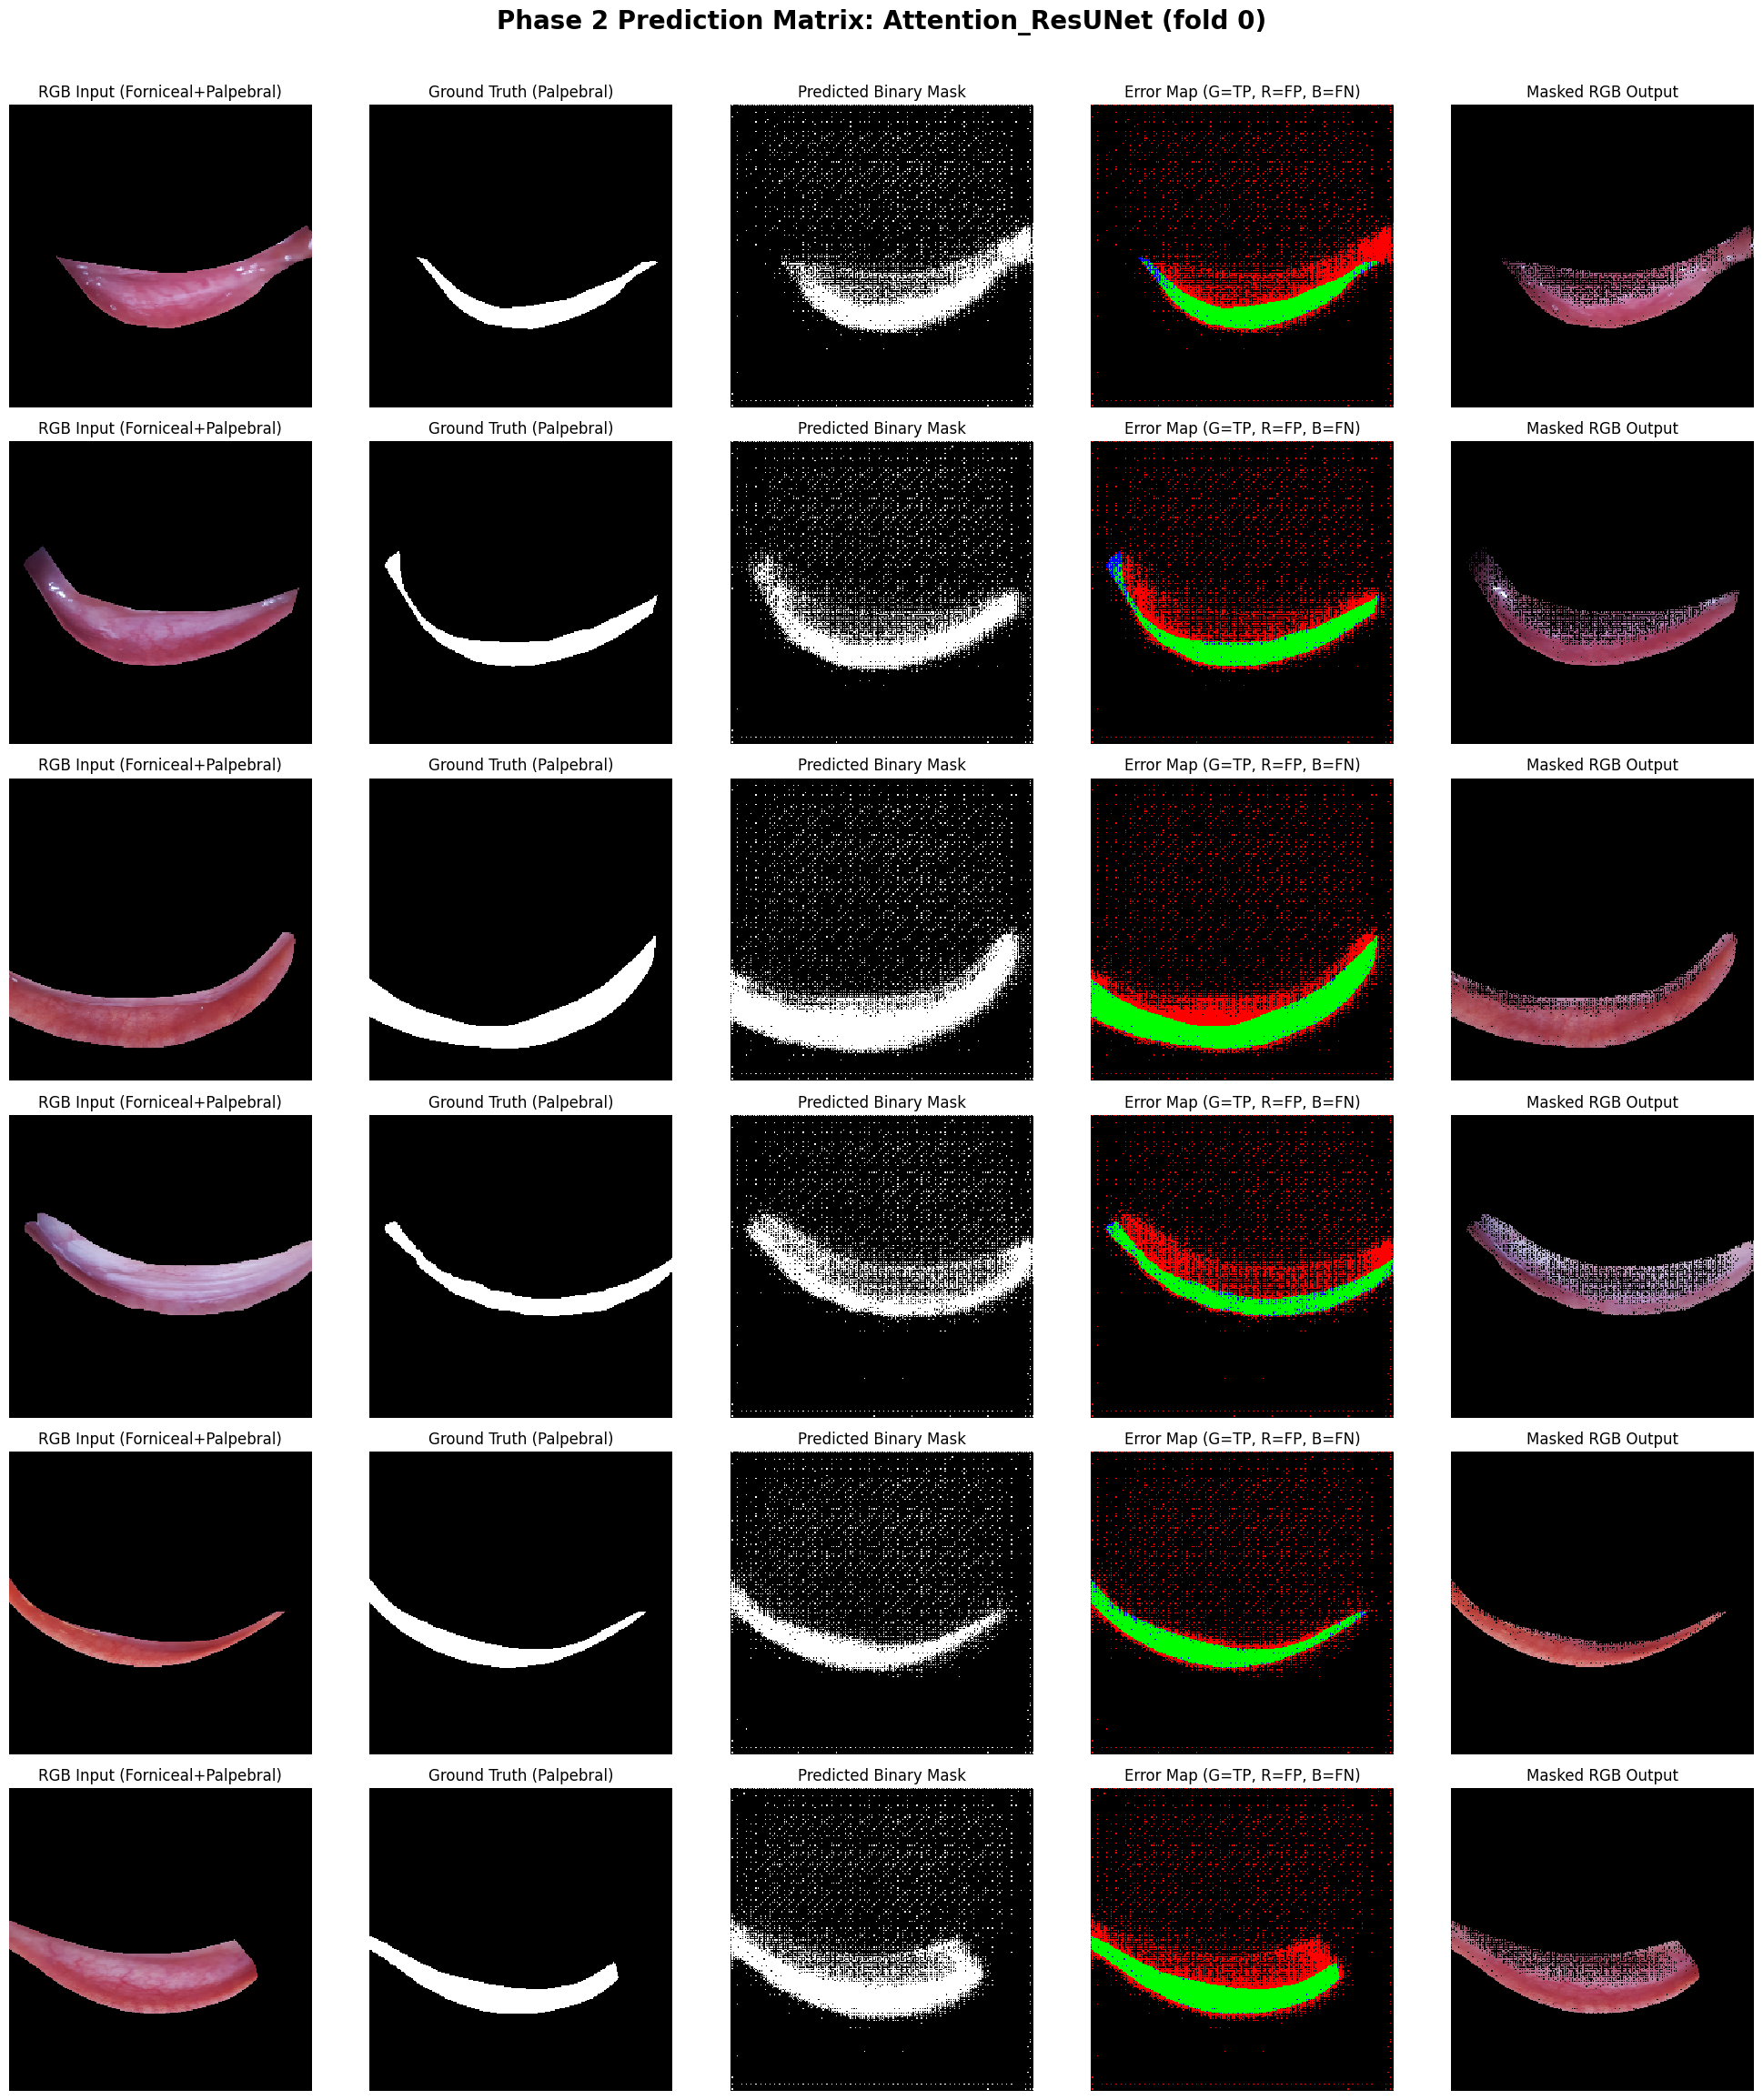

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


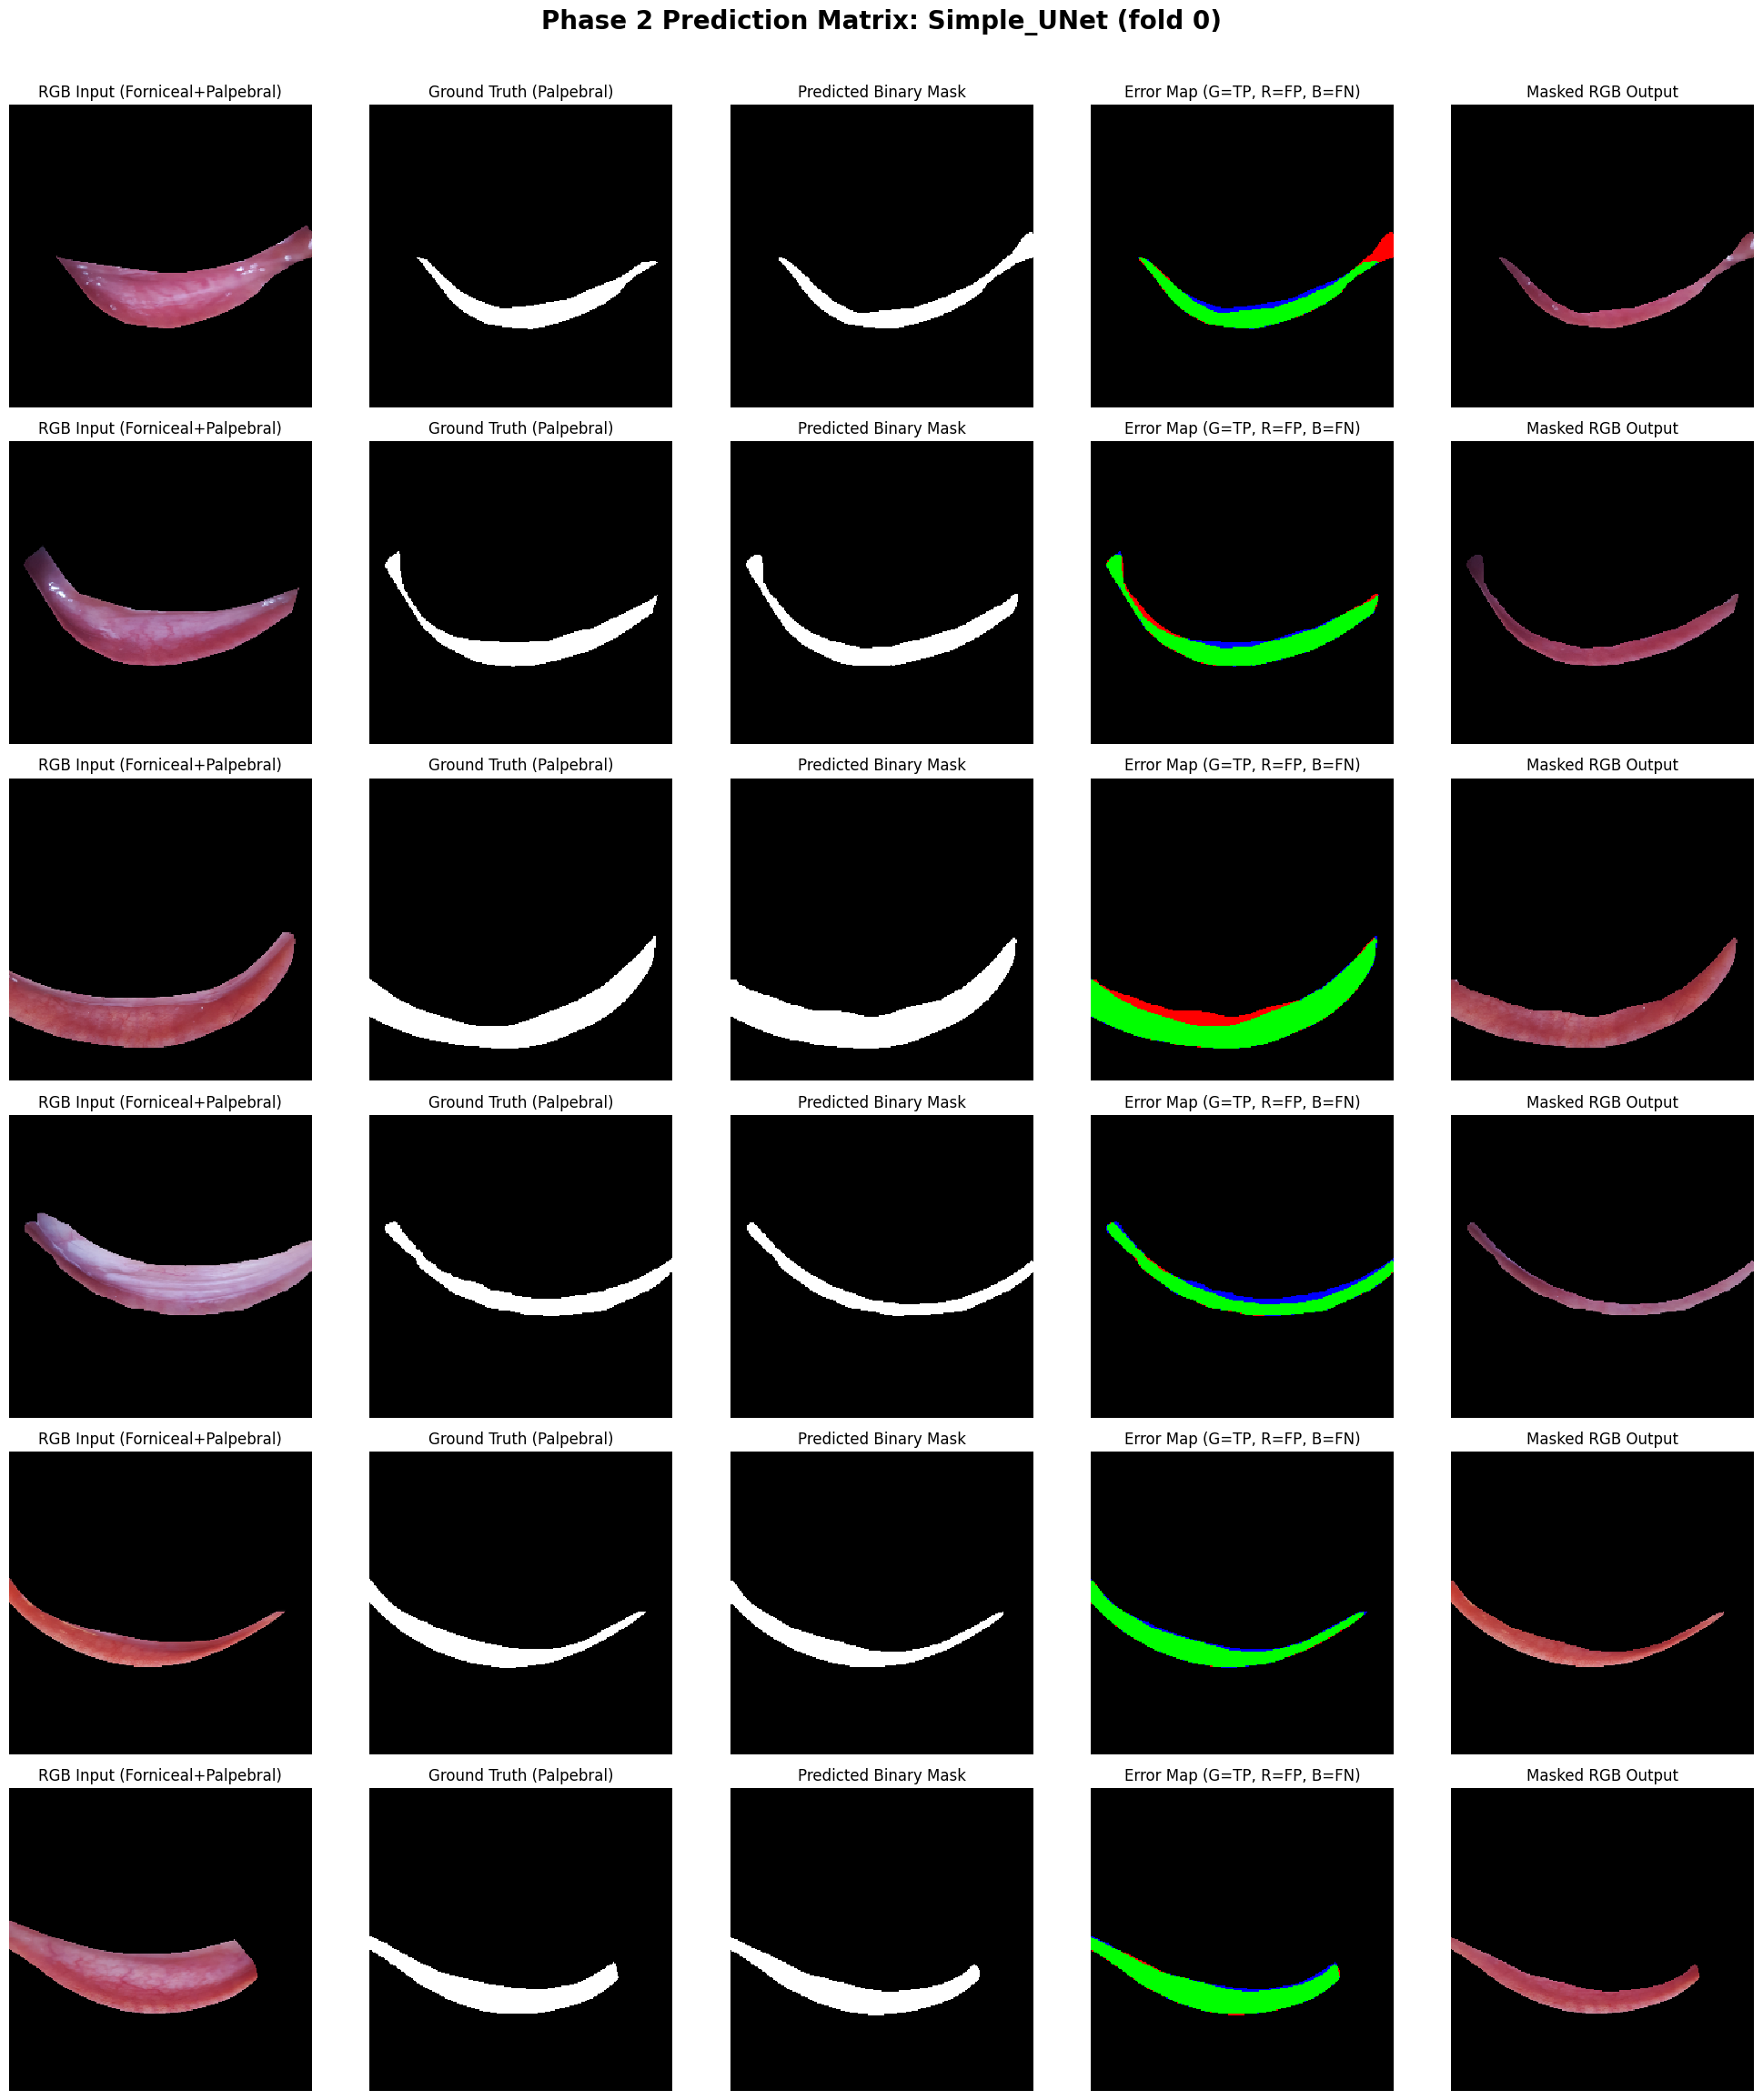

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


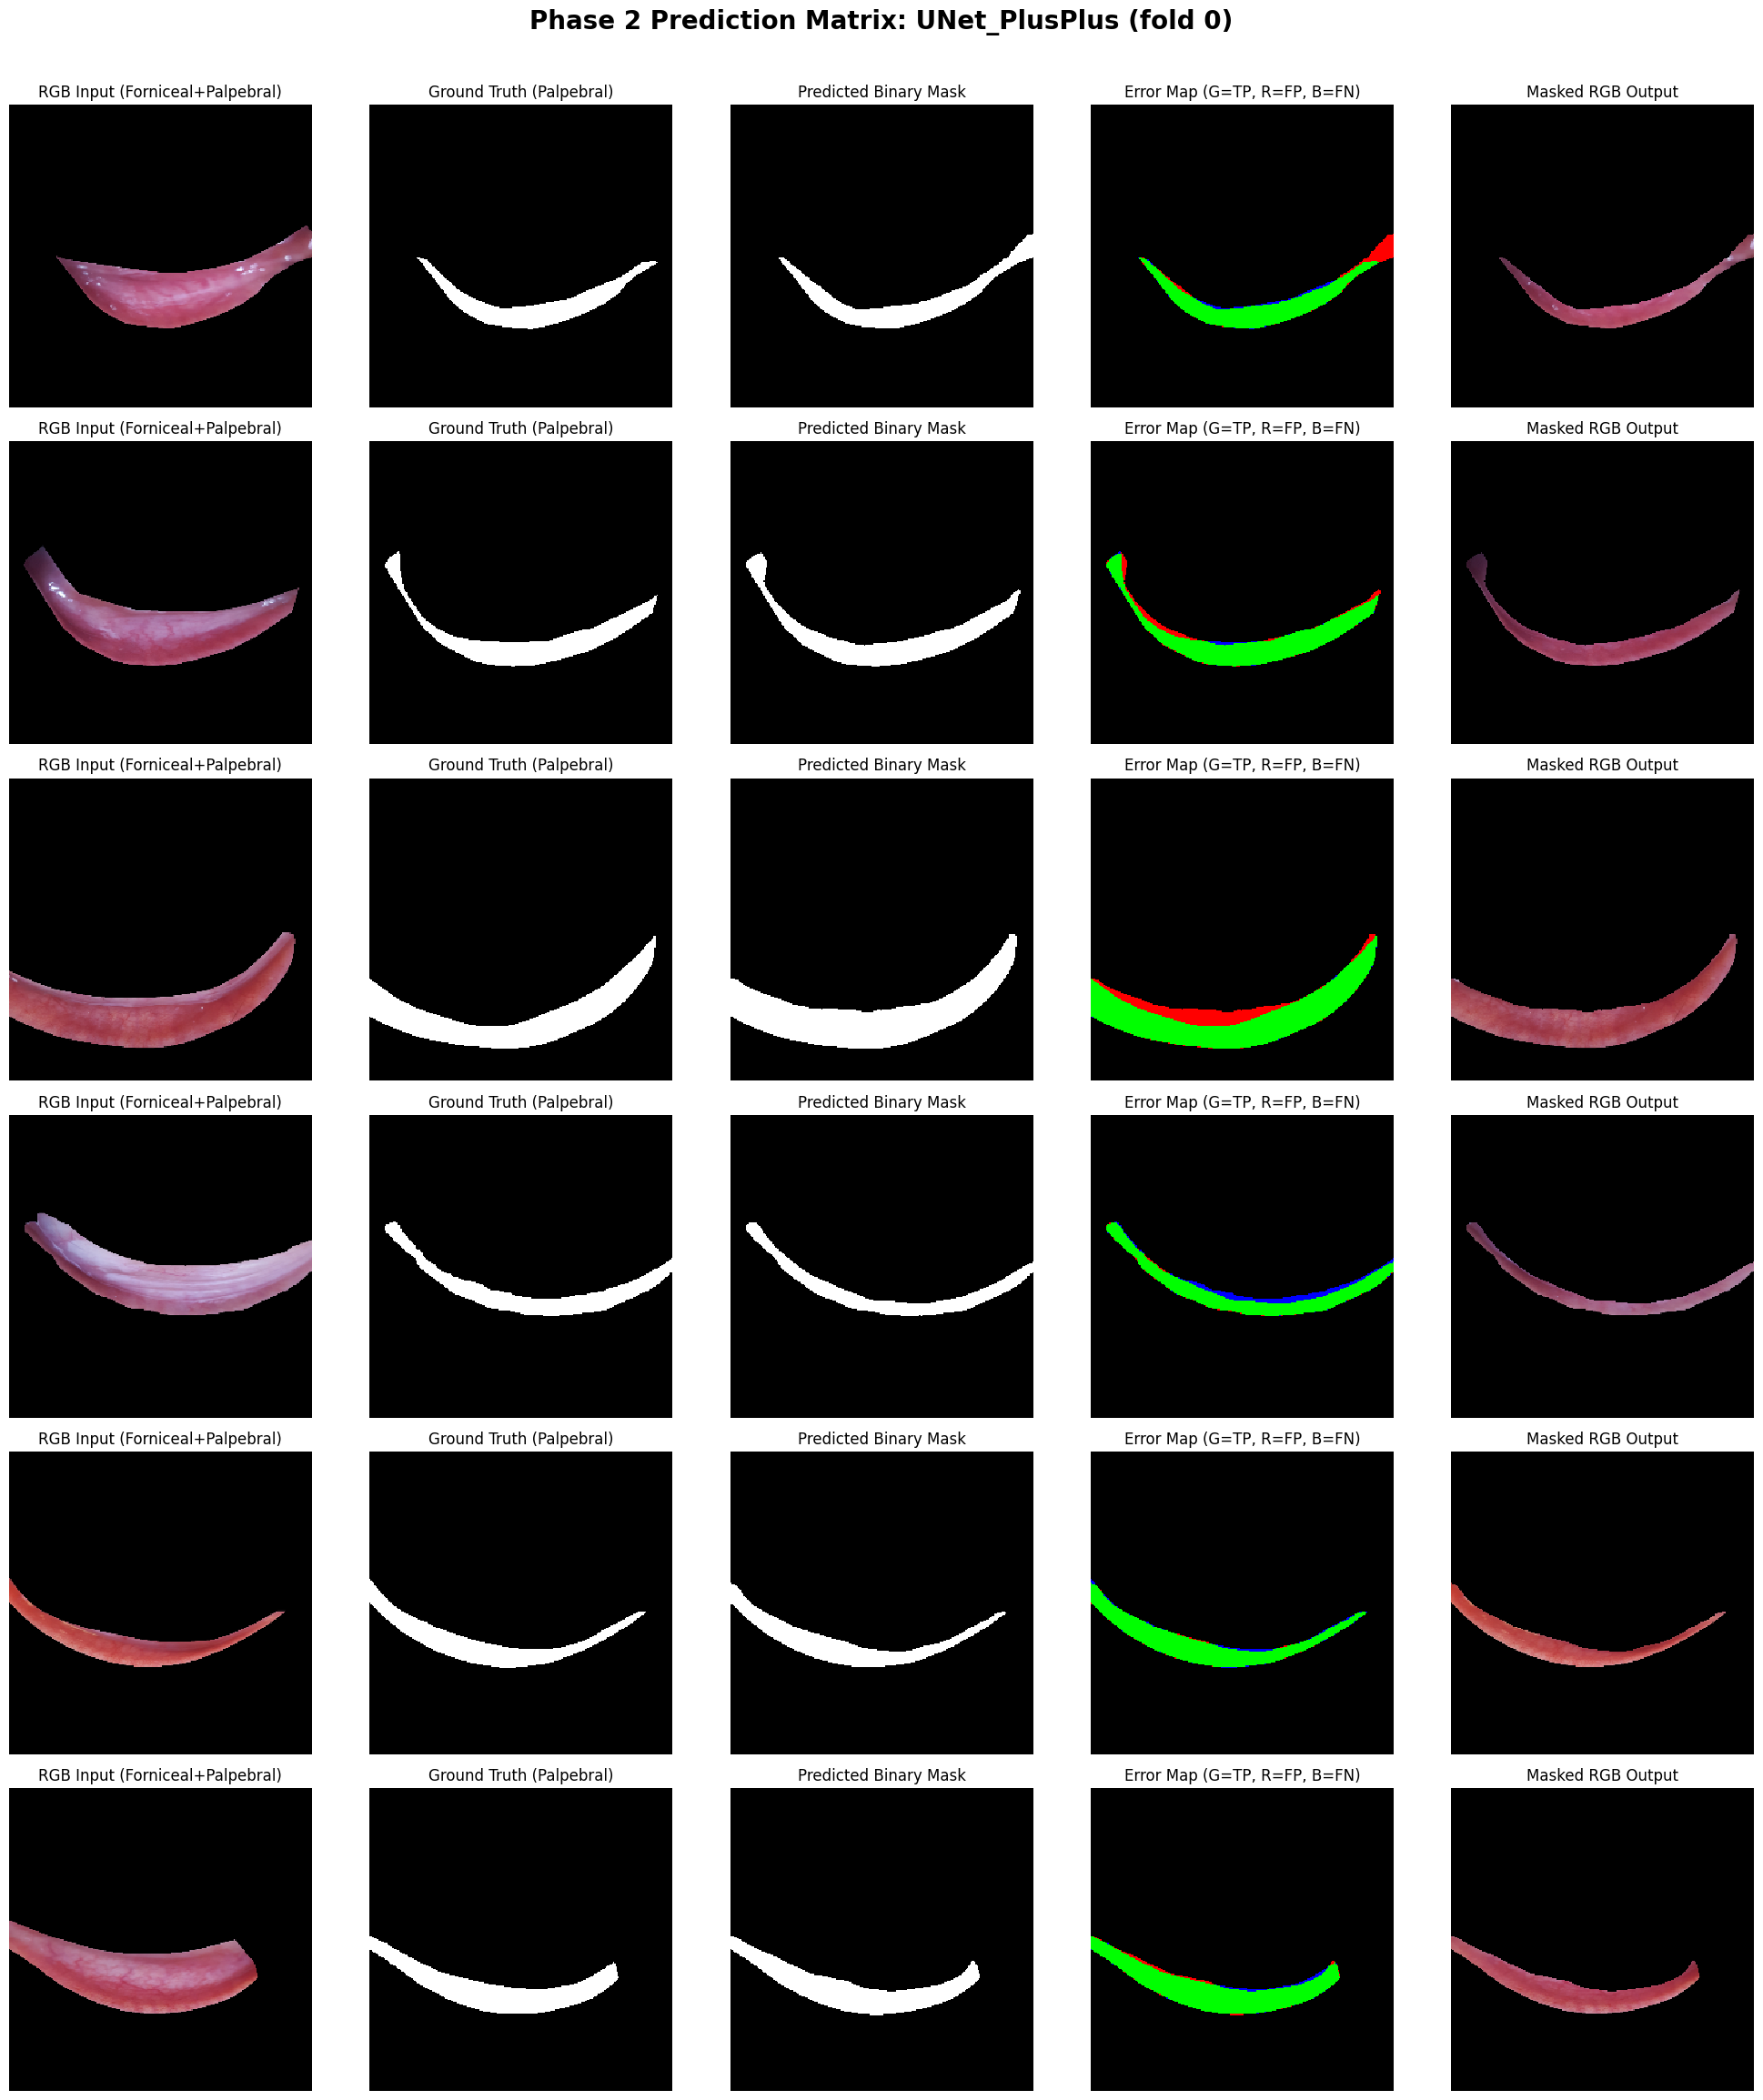

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


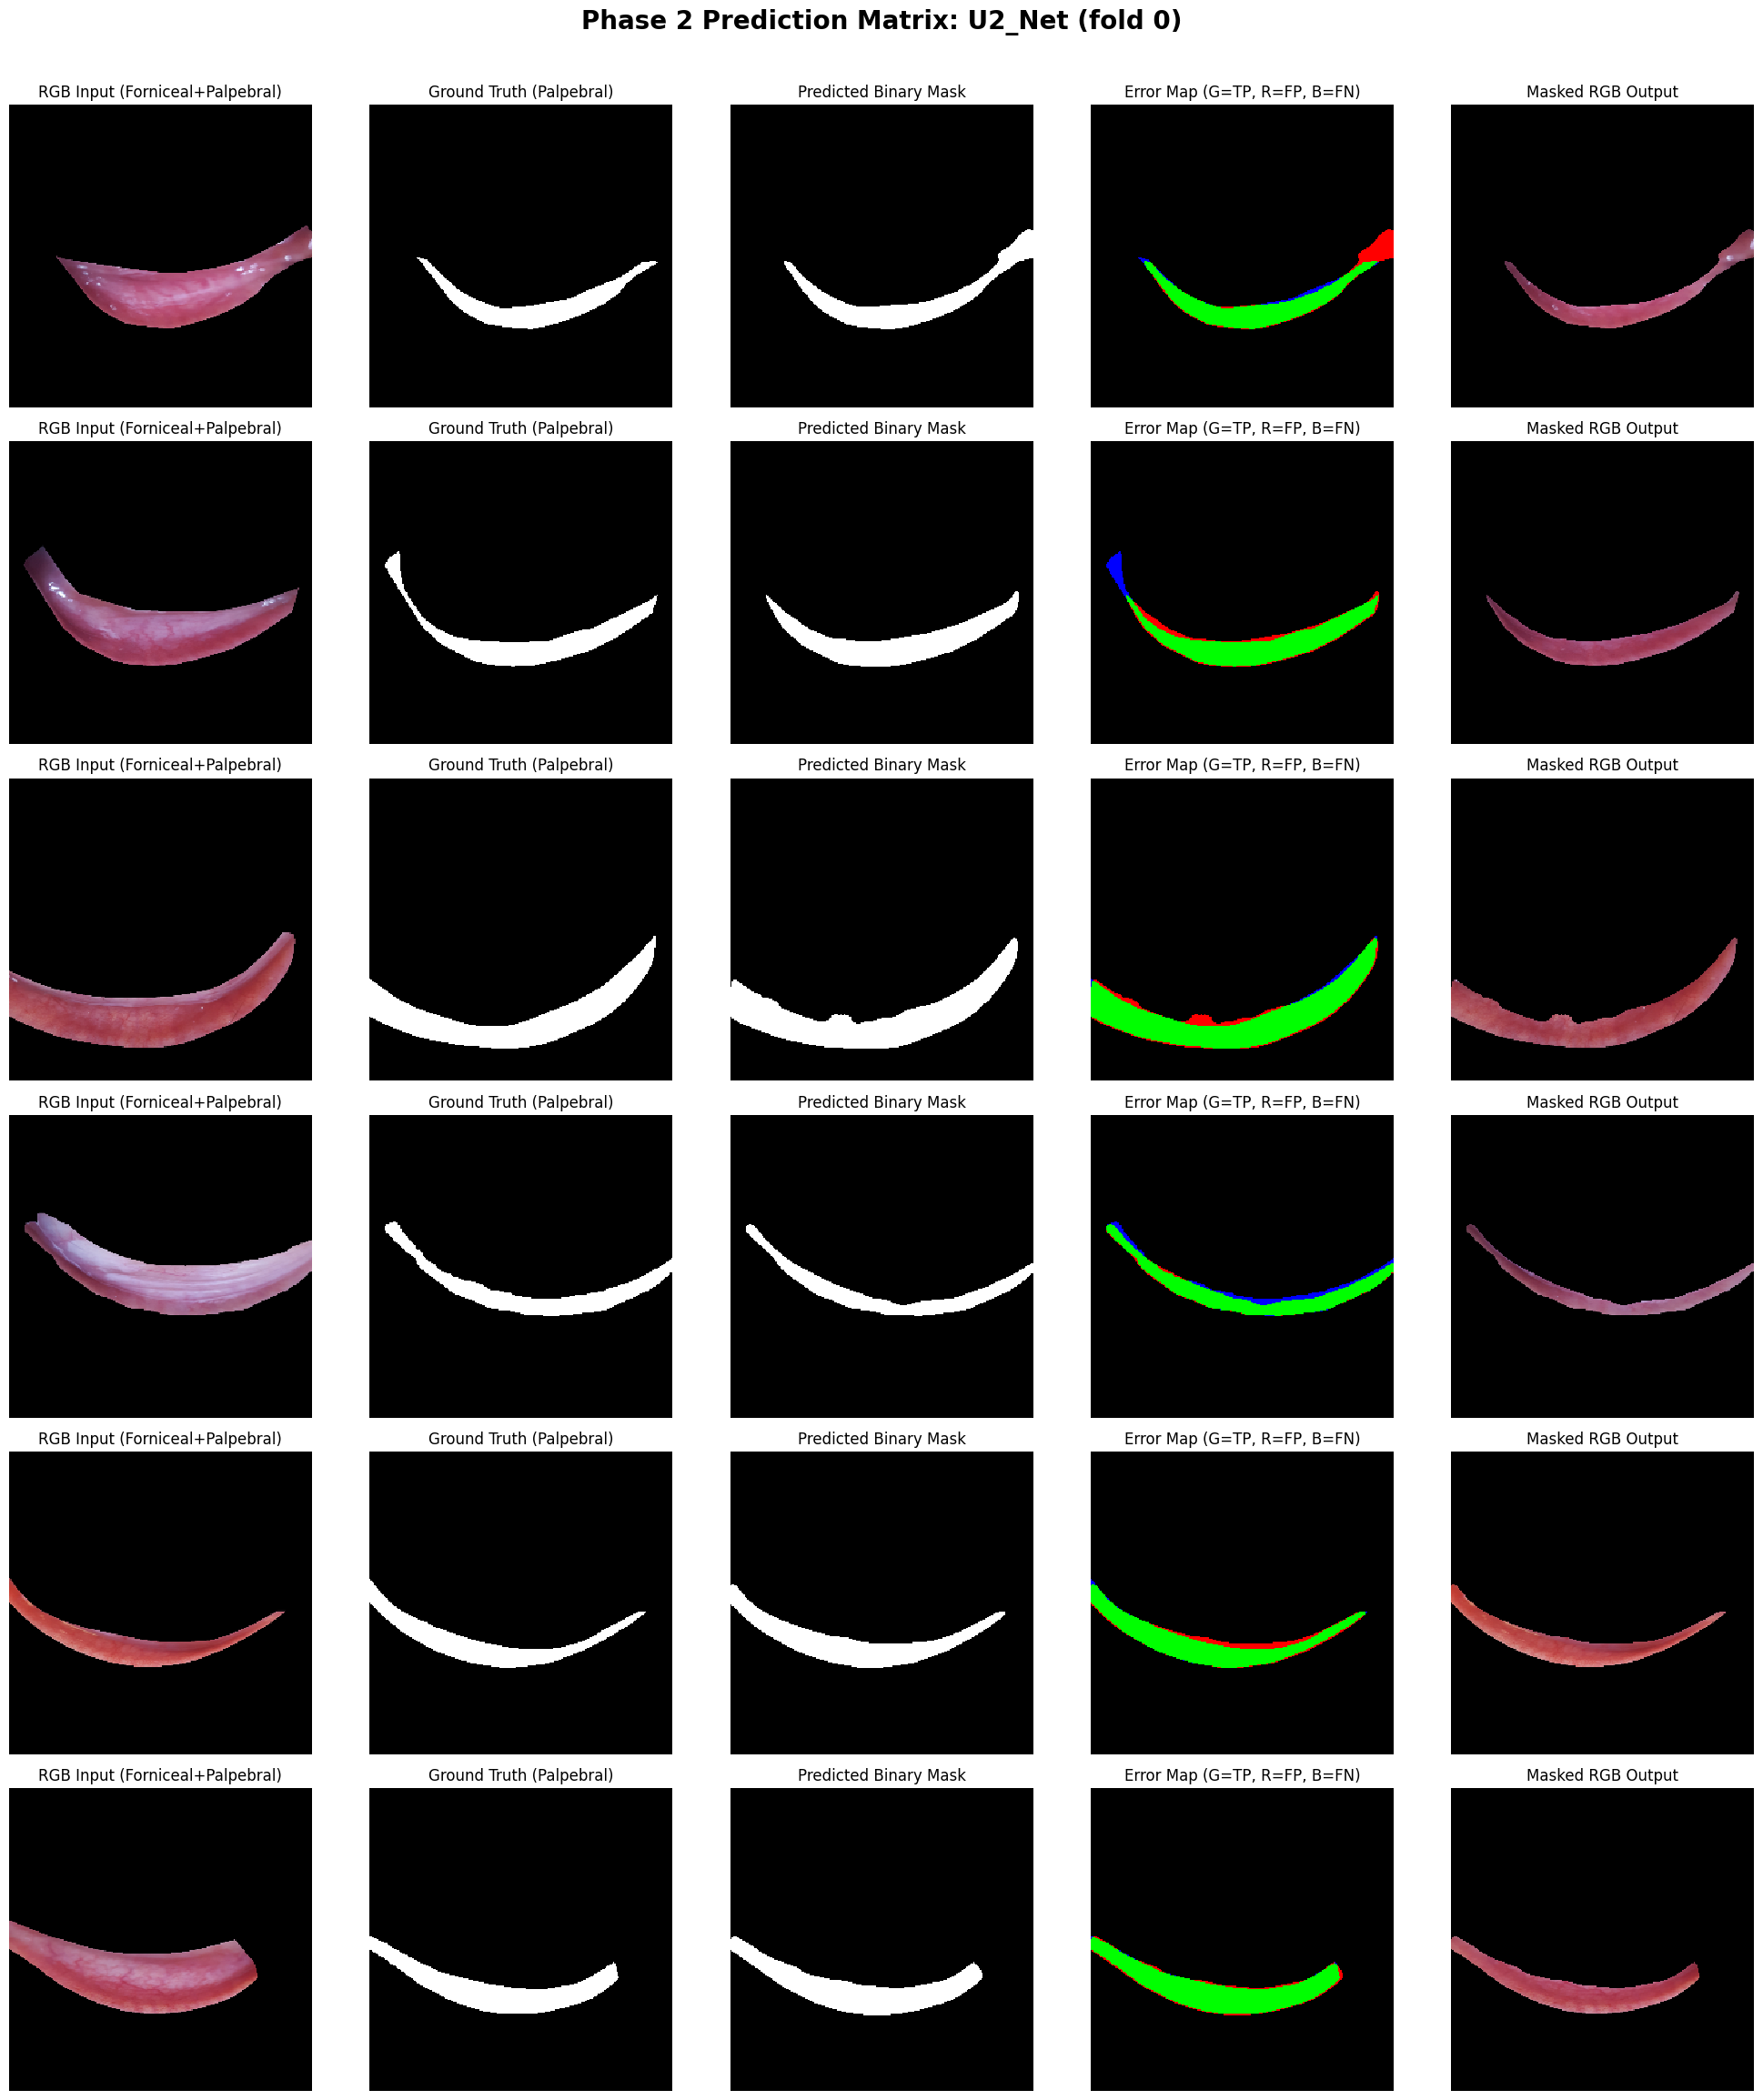

In [15]:
# Block 15: Prediction Analysis Matrix (Restored Masked RGB Output)
# ==========================================================
# FIX 1 (the real cause of the broken pictures):
#   models_dict was built once by get_fresh_models() and NEVER trained.
#   The K-Fold loop in block 13 trains a private copy
#   (current_model = get_fresh_models()[model_name]) and only the .pth files
#   carry the learned weights, so this cell was plotting UNTRAINED networks.
#   That is exactly what the screenshots show: grey noise (Attention_ResUNet),
#   all white with a fully red error map (Simple_UNet), noisy blobs (UNet++),
#   all black with a pure blue error map (U2_Net).
#   Trained fold weights are now loaded before anything is plotted.
#
# FIX 2 (rendering):
#   imshow defaults to interpolation='antialiased' and autoscaled color limits.
#   On a 256x256 binary mask drawn into a much larger axis that produces the
#   dithered/speckled "grey page" look, and a constant mask (all 0 or all 1)
#   gets rescaled to mid grey. vmin=0, vmax=1 plus interpolation='nearest'
#   gives a pure black background with a pure white prediction, and a fully
#   black error map where the pixel is a true negative.
# ==========================================================
VIZ_FOLD = 0   # which fold checkpoint to visualise (0, 1 or 2)

architecture_names = ['Attention_ResUNet', 'Simple_UNet', 'UNet_PlusPlus', 'U2_Net']


def build_single_model(model_name):
    """Builds ONE architecture instead of all four (get_fresh_models builds 4 and throws 3 away)."""
    if model_name == 'Attention_ResUNet':
        return AttentionResUNet(out_channels=1, pretrained=True).to(device)
    elif model_name == 'Simple_UNet':
        return smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                        in_channels=3, classes=1).to(device)
    elif model_name == 'UNet_PlusPlus':
        return smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights="imagenet",
                                in_channels=3, classes=1).to(device)
    elif model_name == 'U2_Net':
        return U2Net_lite(in_ch=3, out_ch=1).to(device)
    raise ValueError(f"Unknown architecture: {model_name}")


def load_trained_model(model_name, fold=0, verbose=True):
    """Loads the checkpoint written by the K-Fold loop of block 13."""
    m = build_single_model(model_name)
    path = f'phase2_{model_name}_fold{fold}.pth'
    if os.path.exists(path):
        m.load_state_dict(torch.load(path, map_location=device))
        if verbose:
            print(f"Loaded trained weights: {path}")
    else:
        print(f"WARNING: {path} not found. {model_name} would be plotted UNTRAINED.")
    m.eval()
    return m


# Trained networks for every architecture (this is what was missing before)
trained_models_dict = {name: load_trained_model(name, VIZ_FOLD) for name in architecture_names}
torch.cuda.empty_cache()

raw_test_dataset = AnemiaDataset(df_test, transforms=None)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Same images for every architecture so the comparison is fair
indices_to_show = random.sample(range(len(test_dataset)), min(6, len(test_dataset)))

for model_name, current_model in trained_models_dict.items():
    current_model.eval()
    fig, axes = plt.subplots(len(indices_to_show), 5, figsize=(20, 4 * len(indices_to_show)))
    plt.suptitle(f'Phase 2 Prediction Matrix: {model_name} (fold {VIZ_FOLD})', fontsize=20, weight='bold')

    for idx_step, idx in enumerate(indices_to_show):
        img_tensor, mask_tensor = test_dataset[idx]

        orig_img = img_tensor.permute(1, 2, 0).numpy()
        orig_img = (orig_img * std + mean)
        orig_img = np.clip(orig_img, 0, 1).astype(np.float32)

        gt_mask = mask_tensor.squeeze().numpy()
        gt_mask = (gt_mask > 0.5).astype(np.float32)   # force a clean 0/1 target

        with torch.no_grad():
            pred_logits = current_model(img_tensor.unsqueeze(0).to(device))
            pred_probs = torch.sigmoid(pred_logits).squeeze().cpu().numpy()
            pred_mask = (pred_probs > 0.5).astype(np.float32)

        # Error map: black background, only TP/FP/FN are colored
        error_map = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype=np.float32)
        tp = (pred_mask == 1) & (gt_mask == 1)
        fp = (pred_mask == 1) & (gt_mask == 0)
        fn = (pred_mask == 0) & (gt_mask == 1)

        error_map[tp] = [0.0, 1.0, 0.0]   # green
        error_map[fp] = [1.0, 0.0, 0.0]   # red
        error_map[fn] = [0.0, 0.0, 1.0]   # blue

        binary_mask_3ch = np.repeat(pred_mask[:, :, np.newaxis], 3, axis=2)
        masked_rgb = orig_img * binary_mask_3ch

        axes[idx_step, 0].imshow(orig_img, interpolation='nearest')
        axes[idx_step, 0].set_title('RGB Input (Forniceal+Palpebral)')
        axes[idx_step, 0].axis('off')

        axes[idx_step, 1].imshow(gt_mask, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        axes[idx_step, 1].set_title('Ground Truth (Palpebral)')
        axes[idx_step, 1].axis('off')

        axes[idx_step, 2].imshow(pred_mask, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        axes[idx_step, 2].set_title('Predicted Binary Mask')
        axes[idx_step, 2].axis('off')

        axes[idx_step, 3].imshow(error_map, vmin=0, vmax=1, interpolation='nearest')
        axes[idx_step, 3].set_title('Error Map (G=TP, R=FP, B=FN)')
        axes[idx_step, 3].axis('off')

        axes[idx_step, 4].imshow(masked_rgb, vmin=0, vmax=1, interpolation='nearest')
        axes[idx_step, 4].set_title('Masked RGB Output')
        axes[idx_step, 4].axis('off')

    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()

Loaded trained weights: phase2_Attention_ResUNet_fold0.pth


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


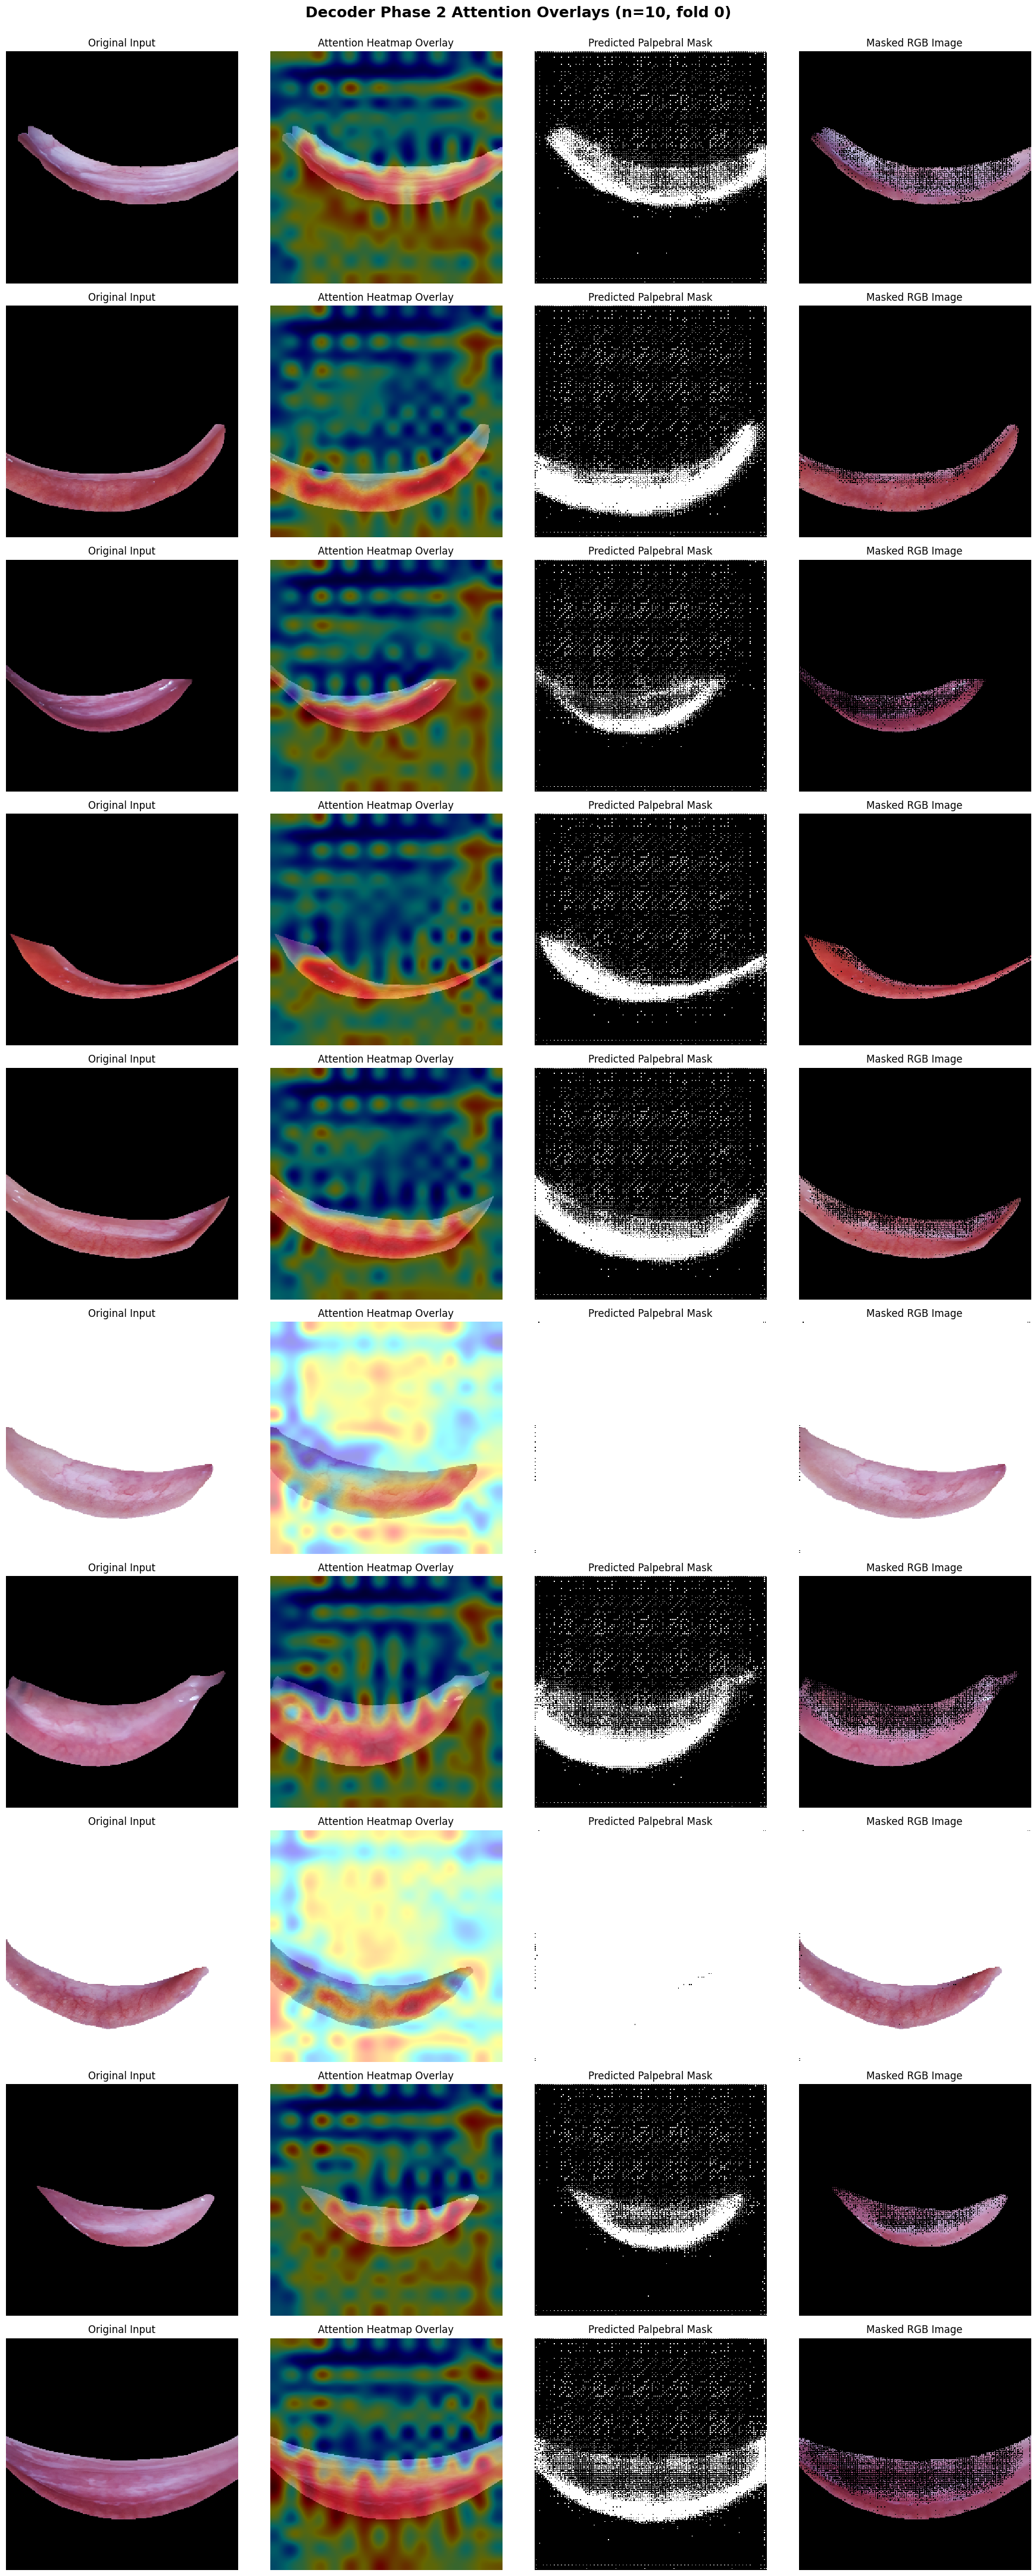

In [16]:
# block 16
# ==========================================================
# FIX: the speckled dots on the predicted mask and on the masked RGB were a
# rendering artifact, not a model artifact. A 256x256 binary image drawn into a
# large axis with the default interpolation='antialiased' gets dithered.
# vmin/vmax plus interpolation='nearest' removes it completely.
# The attention map is also min/max normalised per image so the heatmap shows
# real contrast instead of a flat blue grid.
# ==========================================================
model_name = 'Attention_ResUNet'
model = load_trained_model(model_name, fold=VIZ_FOLD)
model.eval()

n_samples = 10
fig, axes = plt.subplots(n_samples, 4, figsize=(18, 4.5 * n_samples))
plt.suptitle(f'Decoder Phase 2 Attention Overlays (n={n_samples}, fold {VIZ_FOLD})', fontsize=18, weight='bold')

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

viz_indices = random.sample(range(len(test_dataset)), min(n_samples, len(test_dataset)))

for row_idx, idx in enumerate(viz_indices):
    img_tensor, _ = test_dataset[idx]
    orig_img = img_tensor.permute(1, 2, 0).numpy()
    orig_img = np.clip((orig_img * std + mean), 0, 1).astype(np.float32)

    with torch.no_grad():
        pred_logits = model(img_tensor.unsqueeze(0).to(device))
        pred_probs = torch.sigmoid(pred_logits).squeeze().cpu().numpy()
        pred_mask = (pred_probs > 0.5).astype(np.float32)
        att_weights = model.att4.attention_weights.squeeze(0).squeeze(0).cpu().numpy()

    # Smooth upsampling of the 16x16 gate map and per image contrast stretch
    att_map_resized = cv2.resize(att_weights, (orig_img.shape[1], orig_img.shape[0]),
                                 interpolation=cv2.INTER_CUBIC)
    a_min, a_max = float(att_map_resized.min()), float(att_map_resized.max())
    if a_max - a_min > 1e-8:
        att_map_resized = (att_map_resized - a_min) / (a_max - a_min)
    else:
        att_map_resized = np.zeros_like(att_map_resized)
    att_map_resized = np.clip(att_map_resized, 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * att_map_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    overlay = cv2.addWeighted(orig_img, 0.6, heatmap, 0.4, 0)
    overlay = np.clip(overlay, 0, 1)

    binary_mask_3ch = np.repeat(pred_mask[:, :, np.newaxis], 3, axis=2)
    masked_rgb = orig_img * binary_mask_3ch

    axes[row_idx, 0].imshow(orig_img, interpolation='nearest')
    axes[row_idx, 0].set_title('Original Input')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(overlay, vmin=0, vmax=1, interpolation='nearest')
    axes[row_idx, 1].set_title('Attention Heatmap Overlay')
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(pred_mask, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[row_idx, 2].set_title('Predicted Palpebral Mask')
    axes[row_idx, 2].axis('off')

    axes[row_idx, 3].imshow(masked_rgb, vmin=0, vmax=1, interpolation='nearest')
    axes[row_idx, 3].set_title('Masked RGB Image')
    axes[row_idx, 3].axis('off')

plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

In [17]:
#block 17
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

print("=== Phase 2 Architectural Complexity Analysis ===")
param_data = []
for model_name, current_model in models_dict.items():
    total, trainable = count_parameters(current_model)
    param_data.append({
        'Model Architecture': model_name,
        'Total Parameters (M)': f"{total / 1e6:.2f} M",
        'Trainable Parameters (M)': f"{trainable / 1e6:.2f} M"
    })

df_params = pd.DataFrame(param_data)
try:
    from IPython.display import display
    display(df_params)
except ImportError:
    print(df_params.to_string(index=False))

=== Phase 2 Architectural Complexity Analysis ===


,Model Architecture,Total Parameters (M),Trainable Parameters (M)
0,Attention_ResUNet,24.52 M,24.52 M
1,Simple_UNet,24.44 M,24.44 M
2,UNet_PlusPlus,26.08 M,26.08 M
3,U2_Net,0.15 M,0.15 M


In [18]:
# block 18
import zipfile
from IPython.display import FileLink

def zip_phase2_weights(architecture_names, num_splits=3):
    zip_filename = "phase2_palpebral_weights_kfold.zip"
    print("Compiling Phase 2 Palpebral K-Fold Weights...")
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for model_name in architecture_names:
            for fold in range(num_splits):
                file_name = f'phase2_{model_name}_fold{fold}.pth'
                if os.path.exists(file_name):
                    print(f"Added: {file_name}")
                    zipf.write(file_name)
    print(f"File {zip_filename} is ready.")
    return FileLink(zip_filename)

zip_phase2_weights(['Attention_ResUNet', 'Simple_UNet', 'UNet_PlusPlus', 'U2_Net'], num_splits=3)

Compiling Phase 2 Palpebral K-Fold Weights...
Added: phase2_Attention_ResUNet_fold0.pth
Added: phase2_Attention_ResUNet_fold1.pth
Added: phase2_Attention_ResUNet_fold2.pth
Added: phase2_Simple_UNet_fold0.pth
Added: phase2_Simple_UNet_fold1.pth
Added: phase2_Simple_UNet_fold2.pth
Added: phase2_UNet_PlusPlus_fold0.pth
Added: phase2_UNet_PlusPlus_fold1.pth
Added: phase2_UNet_PlusPlus_fold2.pth
Added: phase2_U2_Net_fold0.pth
Added: phase2_U2_Net_fold1.pth
Added: phase2_U2_Net_fold2.pth
File phase2_palpebral_weights_kfold.zip is ready.


/kaggle/working/phase2_palpebral_weights_kfold.zip

In [19]:
# block 19
# ==========================================================
# ADDITIVE BLOCK 1/3 : LOADING EVERY K-FOLD CHECKPOINT
# The K-Fold split of block 5 is kept exactly as it is. This block only
# re-loads the checkpoints that block 13 already wrote to disk and measures
# each of them individually on the untouched holdout test set, so that the
# ensemble and the soup can be compared against a real per fold baseline.
# ==========================================================
architecture_names = ['Attention_ResUNet', 'Simple_UNet', 'UNet_PlusPlus', 'U2_Net']

fold_models = {name: [] for name in architecture_names}
fold_checkpoints = {name: [] for name in architecture_names}
fold_records = []

print("Loading K-Fold checkpoints...")

for model_name in architecture_names:
    for fold in range(n_splits):
        path = f'phase2_{model_name}_fold{fold}.pth'
        if not os.path.exists(path):
            print(f"WARNING: {path} missing, skipped.")
            continue

        m = load_trained_model(model_name, fold=fold, verbose=False)
        fold_models[model_name].append(m)
        fold_checkpoints[model_name].append(path)

        test_loss, test_met = validate(m, test_loader, criterion, device)
        p, r = test_met['precision'], test_met['recall']
        f1 = 2 * (p * r) / (p + r + 1e-6)

        fold_records.append({
            'Architecture': model_name,
            'Fold': fold,
            'Test Loss': test_loss,
            'Test Dice': test_met['dice'],
            'Test IoU': test_met['iou'],
            'Test Precision': p,
            'Test Recall': r,
            'Test F1': f1,
        })
        print(f"{model_name} fold {fold} | Test Dice: {test_met['dice']:.5f} | IoU: {test_met['iou']:.5f}")

df_phase2_folds = pd.DataFrame(fold_records)

print("\n=== PER FOLD TEST RESULTS (individual models) ===")
try:
    from IPython.display import display
    display(df_phase2_folds.round(5))
except ImportError:
    print(df_phase2_folds.round(5).to_string(index=False))

Loading K-Fold checkpoints...


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


Attention_ResUNet fold 0 | Test Dice: 0.86509 | IoU: 0.76603


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


Attention_ResUNet fold 1 | Test Dice: 0.53510 | IoU: 0.37441


...

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


U2_Net fold 1 | Test Dice: 0.96839 | IoU: 0.93913


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


U2_Net fold 2 | Test Dice: 0.95737 | IoU: 0.91937

=== PER FOLD TEST RESULTS (individual models) ===


,Architecture,Fold,Test Loss,Test Dice,Test IoU,Test Precision,Test Recall,Test F1
0,Attention_ResUNet,0,0.53166,0.86509,0.76603,0.77411,0.98487,0.86686
1,Attention_ResUNet,1,0.58825,0.53510,0.37441,0.37447,0.99946,0.54481
2,Attention_ResUNet,2,0.55020,0.69863,0.54703,0.54704,0.99997,0.70720
3,Simple_UNet,0,0.04803,0.98235,0.96552,0.99053,0.97443,0.98241
4,Simple_UNet,1,0.34147,0.93712,0.88308,0.91459,0.96091,0.93718
5,Simple_UNet,2,0.05943,0.97900,0.95904,0.98795,0.97025,0.97902
6,UNet_PlusPlus,0,0.03585,0.98397,0.96857,0.98528,0.98271,0.98399
7,UNet_PlusPlus,1,0.10072,0.97815,0.95745,0.97264,0.98374,0.97816
8,UNet_PlusPlus,2,0.27996,0.96370,0.93041,0.94780,0.98018,0.96372
9,U2_Net,0,0.03280,0.97408,0.94979,0.96851,0.97974,0.97409


In [20]:
# block 20
# ==========================================================
# ADDITIVE BLOCK 2/3 : ENSEMBLE LEARNING (soft voting)
# The sigmoid probabilities of several networks are averaged and only then
# thresholded at 0.5. Metrics are accumulated exactly the way validate() does
# it (same smooth=1.0 as block 11), so the numbers stay comparable with the
# tables produced by block 14.
# ==========================================================
def compute_metrics_from_probs(probs, targets, threshold=0.5):
    preds = (probs > threshold).float().view(-1)
    targets_flat = targets.view(-1)

    tp = (preds * targets_flat).sum().item()
    fp = (preds * (1. - targets_flat)).sum().item()
    fn = ((1. - preds) * targets_flat).sum().item()

    smooth = 1.0   # matched to block 11
    return {
        'dice': (2. * tp + smooth) / (2. * tp + fp + fn + smooth),
        'iou': (tp + smooth) / (tp + fp + fn + smooth),
        'precision': (tp + smooth) / (tp + fp + smooth),
        'recall': (tp + smooth) / (tp + fn + smooth),
    }


def ensemble_loss_from_probs(probs, targets, smooth=1.0):
    """Same 0.5 * BCE + 0.5 * Dice recipe as CombinedLoss, on averaged probabilities."""
    p = probs.clamp(1e-7, 1. - 1e-7)
    bce = F.binary_cross_entropy(p, targets)
    inter = (p.view(-1) * targets.view(-1)).sum()
    dice = (2. * inter + smooth) / (p.sum() + targets.sum() + smooth)
    return 0.5 * bce + 0.5 * (1. - dice)


def evaluate_ensemble(model_list, loader, device, threshold=0.5, weights=None):
    for m in model_list:
        m.eval()

    if weights is None:
        weights = [1.0 / len(model_list)] * len(model_list)
    else:
        total = float(sum(weights))
        weights = [w / total for w in weights]

    running_loss = 0.0
    metrics_summary = {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0}

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            probs = None
            for w, m in zip(weights, model_list):
                p = torch.sigmoid(m(images))
                probs = w * p if probs is None else probs + w * p

            running_loss += ensemble_loss_from_probs(probs, masks).item() * images.size(0)
            batch_metrics = compute_metrics_from_probs(probs, masks, threshold)
            for k in metrics_summary:
                metrics_summary[k] += batch_metrics[k] * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    for k in metrics_summary:
        metrics_summary[k] /= len(loader.dataset)
    return epoch_loss, metrics_summary


ensemble_records = []
ensemble_members = {}


def register_ensemble(tag, member_models):
    ensemble_members[tag] = member_models
    e_loss, e_met = evaluate_ensemble(member_models, test_loader, device)
    p, r = e_met['precision'], e_met['recall']
    f1 = 2 * (p * r) / (p + r + 1e-6)
    ensemble_records.append({
        'Ensemble': tag,
        'Members': len(member_models),
        'Test Loss': e_loss,
        'Test Dice': e_met['dice'],
        'Test IoU': e_met['iou'],
        'Test Precision': p,
        'Test Recall': r,
        'Test F1': f1,
    })
    print(f"{tag:<42} | members: {len(member_models):>2} | Dice: {e_met['dice']:.5f} | IoU: {e_met['iou']:.5f}")
    return e_met


print("=== ENSEMBLE EVALUATION ON THE HOLDOUT TEST SET ===")

# 1. Fold ensemble: the 3 folds of one architecture vote together
for model_name in architecture_names:
    if fold_models[model_name]:
        register_ensemble(f'{model_name} (K-Fold ensemble)', fold_models[model_name])

# 2. Grand ensemble: every fold of every architecture
all_fold_models = [m for name in architecture_names for m in fold_models[name]]
if all_fold_models:
    register_ensemble('All architectures x all folds', all_fold_models)

# 3. Cross architecture ensemble using only one fold per architecture
single_fold_members = [fold_models[name][0] for name in architecture_names if fold_models[name]]
if single_fold_members:
    register_ensemble('Cross architecture (first fold each)', single_fold_members)

df_ensemble = pd.DataFrame(ensemble_records)
print("\n=== ENSEMBLE RESULTS ===")
try:
    from IPython.display import display
    display(df_ensemble.round(5))
except ImportError:
    print(df_ensemble.round(5).to_string(index=False))

=== ENSEMBLE EVALUATION ON THE HOLDOUT TEST SET ===


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


Attention_ResUNet (K-Fold ensemble)        | members:  3 | Dice: 0.82056 | IoU: 0.70231


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


Simple_UNet (K-Fold ensemble)              | members:  3 | Dice: 0.98233 | IoU: 0.96546


...

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


All architectures x all folds              | members: 12 | Dice: 0.98182 | IoU: 0.96445


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


Cross architecture (first fold each)       | members:  4 | Dice: 0.98346 | IoU: 0.96760

=== ENSEMBLE RESULTS ===


,Ensemble,Members,Test Loss,Test Dice,Test IoU,Test Precision,Test Recall,Test F1
0,Attention_ResUNet (K-Fold ensemble),3,0.55543,0.82056,0.70231,0.70243,0.99970,0.82511
1,Simple_UNet (K-Fold ensemble),3,0.15499,0.98233,0.96546,0.98937,0.97546,0.98237
2,UNet_PlusPlus (K-Fold ensemble),3,0.14077,0.98261,0.96596,0.98028,0.98497,0.98262
3,U2_Net (K-Fold ensemble),3,0.04255,0.97087,0.94389,0.97602,0.96605,0.97101
4,All architectures x all folds,12,0.22949,0.98182,0.96445,0.98242,0.98128,0.98185
5,Cross architecture (first fold each),4,0.16983,0.98346,0.96760,0.98536,0.98160,0.98348


In [21]:
# block 21
# ==========================================================
# ADDITIVE BLOCK 3/3 : MODEL SOUP
# Uniform soup : plain average of the weights of the K fold checkpoints
# Greedy soup  : ingredients sorted by score, an ingredient is kept only if
#                the running average improves (Wortsman et al.)
# A soup is ONE network, so inference cost equals a single model, unlike the
# ensemble which needs K forward passes.
#
# Two important notes about this specific notebook:
#  1) Selection set. Every patient outside the test set is used somewhere in
#     the 3 folds, so there is no completely unseen validation pool. Selection
#     is therefore done on the pooled train+val patients. The holdout test set
#     is never used for selection, so the reported test numbers stay honest.
#  2) BatchNorm. block 13 calls get_fresh_models() again for every fold, so the
#     decoders of the folds start from different random inits. Weight averaging
#     likes a shared starting point, so the soup is refreshed with a BatchNorm
#     recalibration pass. The greedy soup can also fall back to a single
#     checkpoint, which makes it safe by construction. If you ever retrain,
#     calling seed_everything(42) right before get_fresh_models() inside the
#     fold loop makes all folds share one init and the soup gets stronger.
# ==========================================================
import copy

SOUP_BN_RECALIBRATION = True
BN_CALIB_BATCHES = 30

# Pooled train+val data, used only for soup selection and BN statistics
df_soup_selection = df_data[~df_data['patient_id'].isin(test_ids)].reset_index(drop=True)
soup_selection_loader = DataLoader(AnemiaDataset(df_soup_selection, transforms=val_test_transforms),
                                   batch_size=16, shuffle=False, num_workers=2)
bn_calib_loader = DataLoader(AnemiaDataset(df_soup_selection, transforms=val_test_transforms),
                             batch_size=16, shuffle=True, num_workers=2)

print(f"Soup selection pool: {len(df_soup_selection)} samples "
      f"({df_soup_selection['patient_id'].nunique()} patients, test set excluded)")


def average_state_dicts(state_dicts):
    """Weight space average. Integer buffers such as num_batches_tracked are copied, not averaged."""
    avg = copy.deepcopy(state_dicts[0])
    for key in avg.keys():
        if avg[key].dtype.is_floating_point:
            stacked = torch.stack([sd[key].float() for sd in state_dicts], dim=0)
            avg[key] = stacked.mean(dim=0).to(avg[key].dtype)
        else:
            avg[key] = state_dicts[0][key].clone()
    return avg


def recalibrate_bn(model, loader, num_batches=BN_CALIB_BATCHES):
    """Recomputes BatchNorm running statistics for the averaged weights."""
    bn_layers = [m for m in model.modules() if isinstance(m, nn.modules.batchnorm._BatchNorm)]
    if not bn_layers:
        return model
    for m in bn_layers:
        m.reset_running_stats()
        m.momentum = None          # cumulative moving average
    model.train()
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            model(images.to(device))
            if i + 1 >= num_batches:
                break
    model.eval()
    return model


def soup_model_from_states(model_name, states):
    m = build_single_model(model_name)
    m.load_state_dict(average_state_dicts(states))
    m.eval()
    if SOUP_BN_RECALIBRATION:
        m = recalibrate_bn(m, bn_calib_loader)
    return m


def make_uniform_soup(model_name):
    states = [torch.load(p, map_location='cpu') for p in fold_checkpoints[model_name]]
    m = soup_model_from_states(model_name, states)
    torch.save(m.state_dict(), f'phase2_soup_uniform_{model_name}.pth')
    return m


def make_greedy_soup(model_name, selection_loader):
    paths = fold_checkpoints[model_name]

    # 1. Rank the ingredients on the selection pool
    scored = []
    for p in paths:
        m = build_single_model(model_name)
        m.load_state_dict(torch.load(p, map_location=device))
        _, met = validate(m, selection_loader, criterion, device)
        scored.append((met['dice'], p))
        print(f"   ingredient {os.path.basename(p)} | selection Dice: {met['dice']:.5f}")
        del m
        torch.cuda.empty_cache()
    scored.sort(key=lambda t: t[0], reverse=True)

    # 2. Add greedily, keep only what improves the running soup
    ingredients, best_dice = [], -1.0
    for dice, p in scored:
        candidate = ingredients + [p]
        states = [torch.load(q, map_location='cpu') for q in candidate]
        m = soup_model_from_states(model_name, states)
        _, met = validate(m, selection_loader, criterion, device)
        del m
        torch.cuda.empty_cache()
        if met['dice'] > best_dice:
            best_dice, ingredients = met['dice'], candidate
            print(f"   accepted {os.path.basename(p)} | soup selection Dice: {best_dice:.5f}")
        else:
            print(f"   rejected {os.path.basename(p)} | would drop to: {met['dice']:.5f}")

    final = soup_model_from_states(model_name, [torch.load(q, map_location='cpu') for q in ingredients])
    torch.save(final.state_dict(), f'phase2_soup_greedy_{model_name}.pth')
    return final, ingredients, best_dice


soup_models = {}
soup_records = []

for model_name in architecture_names:
    if not fold_checkpoints[model_name]:
        continue
    print(f"\n{'='*55}\nCooking soups for: {model_name}\n{'='*55}")

    uni_model = make_uniform_soup(model_name)
    uni_loss, uni_met = validate(uni_model, test_loader, criterion, device)
    print(f"Uniform soup | Test Dice: {uni_met['dice']:.5f} | IoU: {uni_met['iou']:.5f}")

    print("Greedy soup selection:")
    gre_model, gre_ingredients, gre_sel_dice = make_greedy_soup(model_name, soup_selection_loader)
    gre_loss, gre_met = validate(gre_model, test_loader, criterion, device)
    print(f"Greedy soup  | ingredients: {len(gre_ingredients)}/{len(fold_checkpoints[model_name])} | "
          f"Test Dice: {gre_met['dice']:.5f} | IoU: {gre_met['iou']:.5f}")

    soup_models[f'{model_name}_uniform_soup'] = uni_model
    soup_models[f'{model_name}_greedy_soup'] = gre_model

    p_u, r_u = uni_met['precision'], uni_met['recall']
    p_g, r_g = gre_met['precision'], gre_met['recall']

    soup_records.append({
        'Architecture': model_name,
        'Fold Mean Dice': df_phase2_folds[df_phase2_folds['Architecture'] == model_name]['Test Dice'].mean(),
        'Uniform Soup Dice': uni_met['dice'],
        'Uniform Soup IoU': uni_met['iou'],
        'Uniform Soup F1': 2 * (p_u * r_u) / (p_u + r_u + 1e-6),
        'Greedy Soup Dice': gre_met['dice'],
        'Greedy Soup IoU': gre_met['iou'],
        'Greedy Soup F1': 2 * (p_g * r_g) / (p_g + r_g + 1e-6),
        'Greedy Ingredients': len(gre_ingredients),
    })

df_soup = pd.DataFrame(soup_records)
print("\n=== MODEL SOUP RESULTS (holdout test set) ===")
try:
    from IPython.display import display
    display(df_soup.round(5))
except ImportError:
    print(df_soup.round(5).to_string(index=False))

# The soups are single models, so they can also vote together as an ensemble
uniform_soup_members = [soup_models[f'{n}_uniform_soup'] for n in architecture_names
                        if f'{n}_uniform_soup' in soup_models]
greedy_soup_members = [soup_models[f'{n}_greedy_soup'] for n in architecture_names
                       if f'{n}_greedy_soup' in soup_models]

print("\n=== SOUP BASED ENSEMBLES ===")
if uniform_soup_members:
    register_ensemble('Uniform soups ensemble', uniform_soup_members)
if greedy_soup_members:
    register_ensemble('Greedy soups ensemble', greedy_soup_members)

df_ensemble = pd.DataFrame(ensemble_records)

Soup selection pool: 177 samples (177 patients, test set excluded)

Cooking soups for: Attention_ResUNet


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

Uniform soup | Test Dice: 0.40546 | IoU: 0.26066
Greedy soup selection:


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

   ingredient phase2_Attention_ResUNet_fold0.pth | selection Dice: 0.69982


...


=== SOUP BASED ENSEMBLES ===


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


Uniform soups ensemble                     | members:  4 | Dice: 0.03386 | IoU: 0.01723


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


Greedy soups ensemble                      | members:  4 | Dice: 0.96925 | IoU: 0.94105


=== PHASE 2 FINAL COMPARISON (Test Dice) ===


,Architecture,Fold Mean Dice,Fold Std Dice,Best Single Fold Dice,Uniform Soup Dice,Greedy Soup Dice,K-Fold Ensemble Dice,Best Strategy
0,Attention_ResUNet,0.69961,0.16500,0.86509,0.40546,0.84692,0.82056,Best Single Fold Dice
1,Simple_UNet,0.96616,0.02520,0.98235,0.25888,0.71178,0.98233,Best Single Fold Dice
2,UNet_PlusPlus,0.97527,0.01044,0.98397,0.25108,0.97001,0.98261,Best Single Fold Dice
3,U2_Net,0.96661,0.00850,0.97408,0.00000,0.12831,0.97087,Best Single Fold Dice


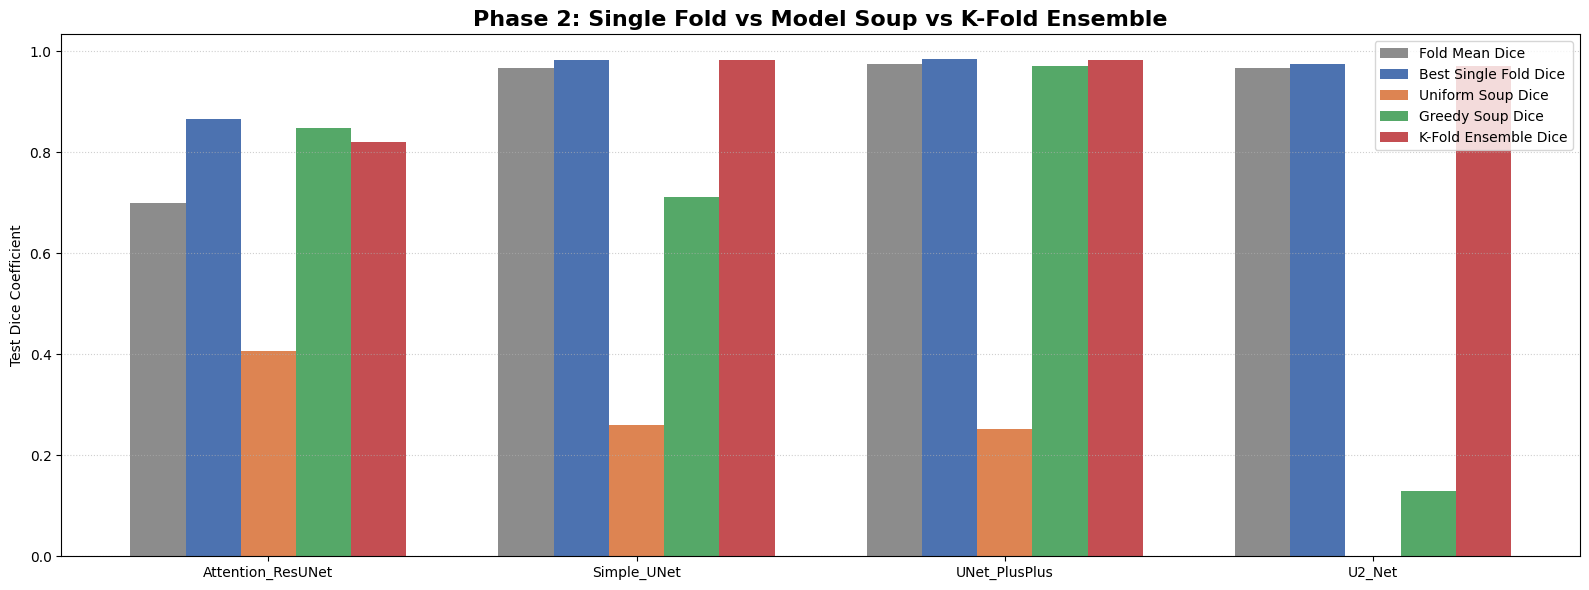


=== GLOBAL ENSEMBLES (mixed architectures) ===


,Ensemble,Members,Test Loss,Test Dice,Test IoU,Test Precision,Test Recall,Test F1
0,All architectures x all folds,12,0.22949,0.98182,0.96445,0.98242,0.98128,0.98185
1,Cross architecture (first fold each),4,0.16983,0.98346,0.96760,0.98536,0.98160,0.98348
2,Uniform soups ensemble,4,0.62874,0.03386,0.01723,0.80046,0.01731,0.03388
3,Greedy soups ensemble,4,0.36287,0.96925,0.94105,0.98912,0.95095,0.96966



=== OVERALL LEADERBOARD ===


,Method,Type,Test Dice,Test IoU
0,UNet_PlusPlus fold 0,Single model,0.98397,0.96857
1,Cross architecture (first fold each),Ensemble,0.98346,0.96760
2,UNet_PlusPlus (K-Fold ensemble),Ensemble,0.98261,0.96596
3,Simple_UNet fold 0,Single model,0.98235,0.96552
4,Simple_UNet (K-Fold ensemble),Ensemble,0.98233,0.96546
5,All architectures x all folds,Ensemble,0.98182,0.96445
6,Simple_UNet fold 2,Single model,0.97900,0.95904
7,UNet_PlusPlus fold 1,Single model,0.97815,0.95745
8,U2_Net fold 0,Single model,0.97408,0.94979
9,U2_Net (K-Fold ensemble),Ensemble,0.97087,0.94389


In [22]:
# block 22
# ==========================================================
# COMPARISON : single fold model vs K-Fold ensemble vs model soup
# Every number below is measured on the same untouched holdout test set.
# ==========================================================
comparison_rows = []

for model_name in architecture_names:
    sub_folds = df_phase2_folds[df_phase2_folds['Architecture'] == model_name]
    if sub_folds.empty:
        continue
    sub_soup = df_soup[df_soup['Architecture'] == model_name]
    ens_tag = f'{model_name} (K-Fold ensemble)'
    sub_ens = df_ensemble[df_ensemble['Ensemble'] == ens_tag]

    comparison_rows.append({
        'Architecture': model_name,
        'Fold Mean Dice': sub_folds['Test Dice'].mean(),
        'Fold Std Dice': sub_folds['Test Dice'].std(),
        'Best Single Fold Dice': sub_folds['Test Dice'].max(),
        'Uniform Soup Dice': sub_soup['Uniform Soup Dice'].iloc[0] if not sub_soup.empty else np.nan,
        'Greedy Soup Dice': sub_soup['Greedy Soup Dice'].iloc[0] if not sub_soup.empty else np.nan,
        'K-Fold Ensemble Dice': sub_ens['Test Dice'].iloc[0] if not sub_ens.empty else np.nan,
    })

df_final_comparison = pd.DataFrame(comparison_rows)
df_final_comparison['Best Strategy'] = df_final_comparison[
    ['Fold Mean Dice', 'Best Single Fold Dice', 'Uniform Soup Dice', 'Greedy Soup Dice', 'K-Fold Ensemble Dice']
].idxmax(axis=1)

print("=== PHASE 2 FINAL COMPARISON (Test Dice) ===")
try:
    from IPython.display import display
    display(df_final_comparison.round(5))
except ImportError:
    print(df_final_comparison.round(5).to_string(index=False))

# Grouped bar chart
strategies = ['Fold Mean Dice', 'Best Single Fold Dice', 'Uniform Soup Dice',
              'Greedy Soup Dice', 'K-Fold Ensemble Dice']
bar_colors = ['#8c8c8c', '#4c72b0', '#dd8452', '#55a868', '#c44e52']

x = np.arange(len(df_final_comparison))
width = 0.15

plt.figure(figsize=(16, 6))
for i, (strategy, color) in enumerate(zip(strategies, bar_colors)):
    plt.bar(x + (i - 2) * width, df_final_comparison[strategy].values, width, label=strategy, color=color)

plt.xticks(x, df_final_comparison['Architecture'].values)
plt.ylabel('Test Dice Coefficient')
plt.title('Phase 2: Single Fold vs Model Soup vs K-Fold Ensemble', fontsize=16, weight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Ensembles that mix architectures are reported separately
print("\n=== GLOBAL ENSEMBLES (mixed architectures) ===")
global_tags = ['All architectures x all folds', 'Cross architecture (first fold each)',
               'Uniform soups ensemble', 'Greedy soups ensemble']
df_global = df_ensemble[df_ensemble['Ensemble'].isin(global_tags)].reset_index(drop=True)
try:
    from IPython.display import display
    display(df_global.round(5))
except ImportError:
    print(df_global.round(5).to_string(index=False))

# Overall leaderboard across everything that was evaluated
leaderboard = []
for _, row in df_phase2_folds.iterrows():
    leaderboard.append({'Method': f"{row['Architecture']} fold {int(row['Fold'])}",
                        'Type': 'Single model', 'Test Dice': row['Test Dice'], 'Test IoU': row['Test IoU']})
for _, row in df_soup.iterrows():
    leaderboard.append({'Method': f"{row['Architecture']} uniform soup",
                        'Type': 'Model soup', 'Test Dice': row['Uniform Soup Dice'], 'Test IoU': row['Uniform Soup IoU']})
    leaderboard.append({'Method': f"{row['Architecture']} greedy soup",
                        'Type': 'Model soup', 'Test Dice': row['Greedy Soup Dice'], 'Test IoU': row['Greedy Soup IoU']})
for _, row in df_ensemble.iterrows():
    leaderboard.append({'Method': row['Ensemble'], 'Type': 'Ensemble',
                        'Test Dice': row['Test Dice'], 'Test IoU': row['Test IoU']})

df_leaderboard = pd.DataFrame(leaderboard).sort_values('Test Dice', ascending=False).reset_index(drop=True)
print("\n=== OVERALL LEADERBOARD ===")
try:
    from IPython.display import display
    display(df_leaderboard.round(5))
except ImportError:
    print(df_leaderboard.round(5).to_string(index=False))

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


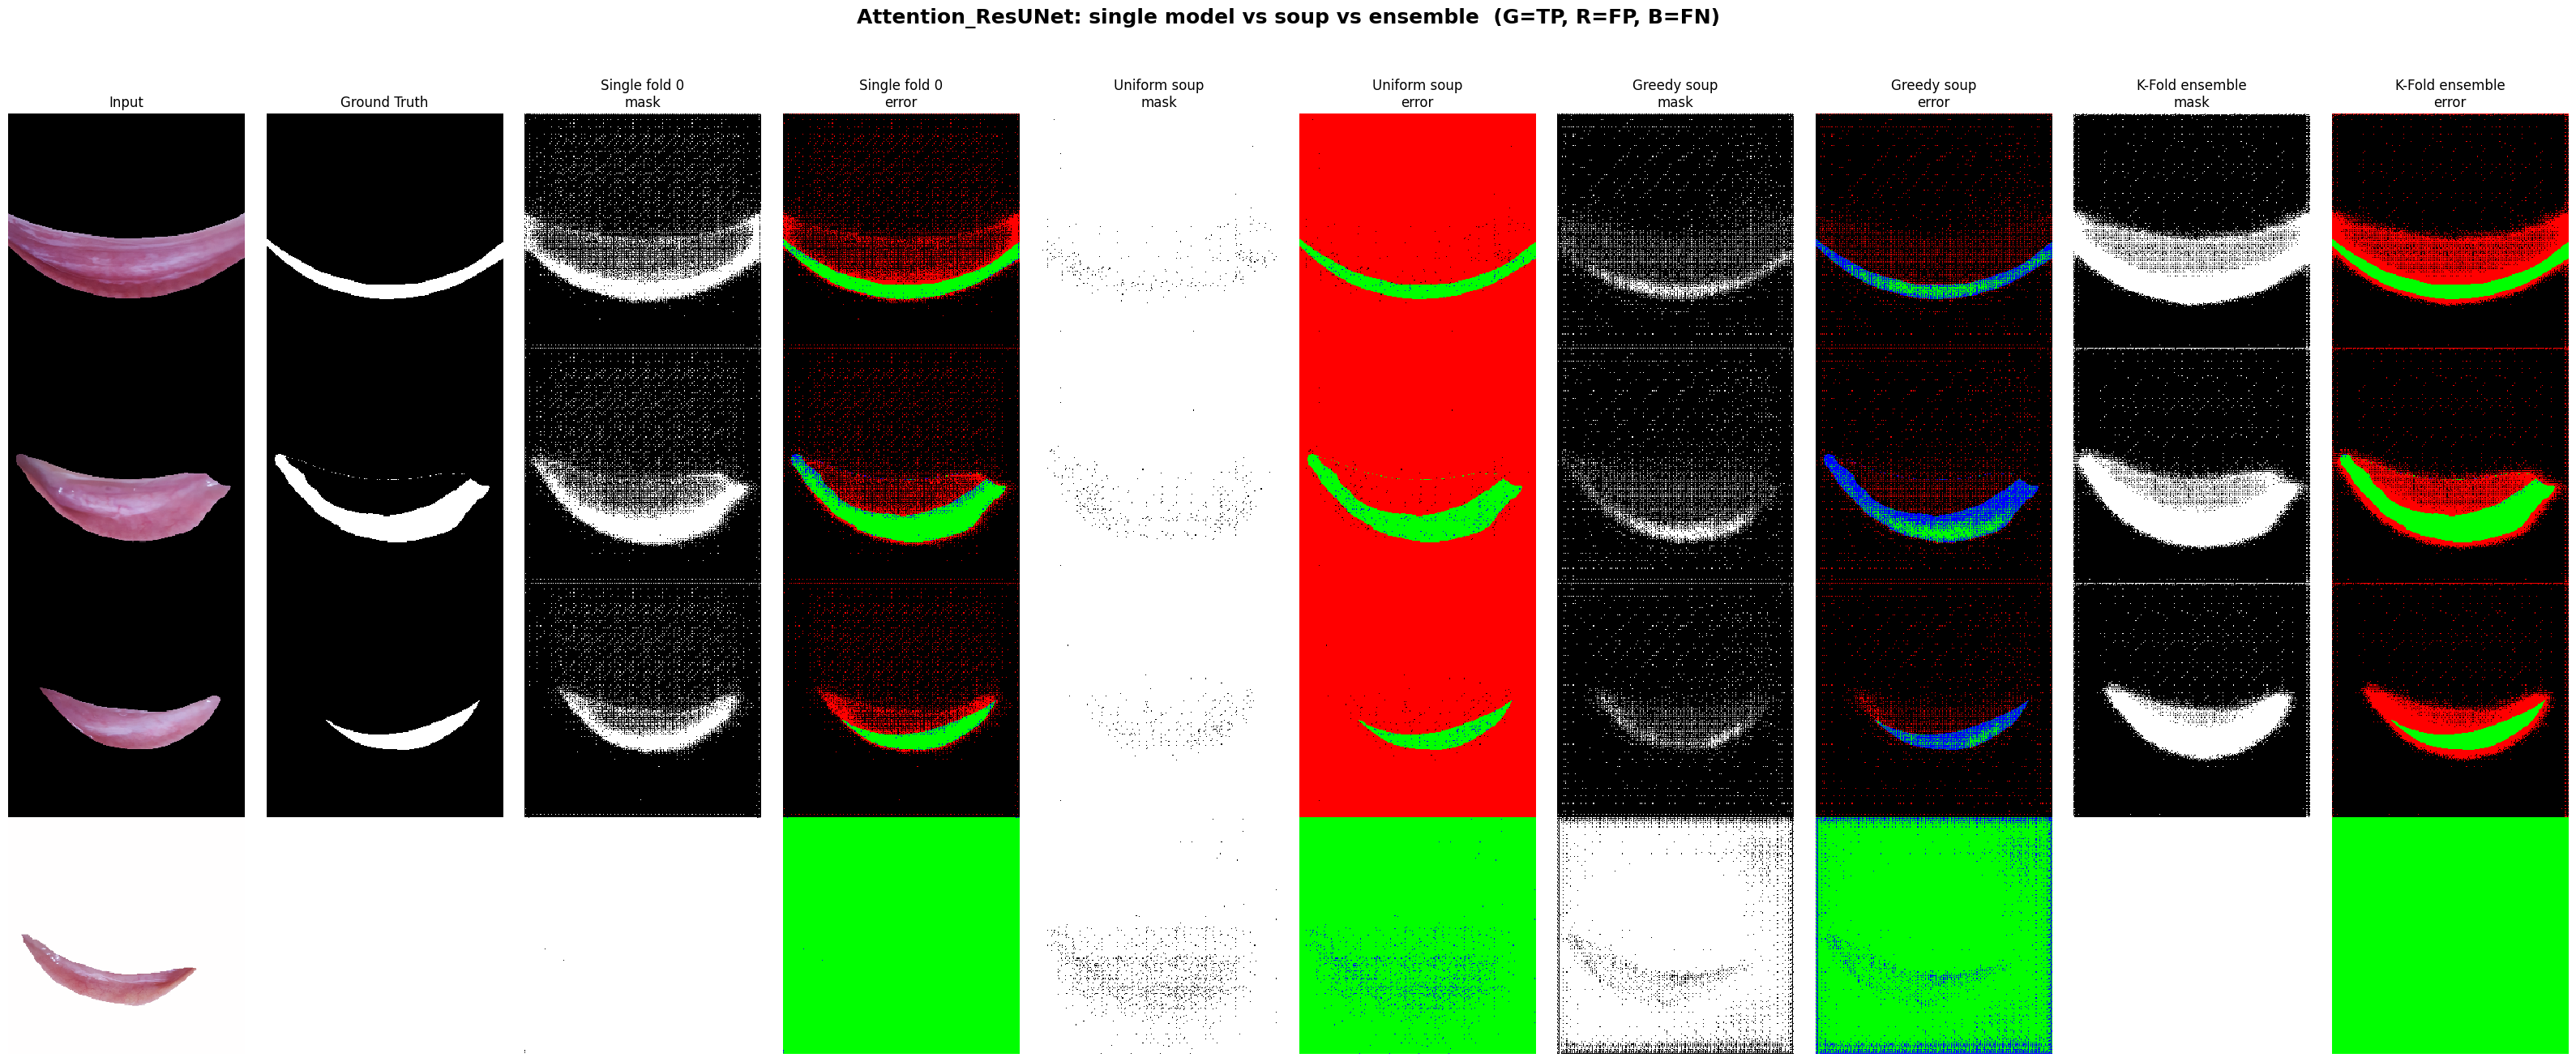

Soup checkpoints packed into phase2_soup_weights.zip


/kaggle/working/phase2_soup_weights.zip

In [23]:
# block 23
# ==========================================================
# QUALITATIVE COMPARISON : single fold vs soup vs ensemble
# Same rendering rules as the fixed block 15 (vmin/vmax and nearest
# interpolation), so a black background stays black and the mask stays binary.
# ==========================================================
VIZ_ARCH = 'Attention_ResUNet'

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

single_model = fold_models[VIZ_ARCH][0]
uniform_soup_model = soup_models.get(f'{VIZ_ARCH}_uniform_soup')
greedy_soup_model = soup_models.get(f'{VIZ_ARCH}_greedy_soup')
kfold_ensemble_members = fold_models[VIZ_ARCH]


def predict_mask(model_or_list, img_tensor, threshold=0.5):
    models_list = model_or_list if isinstance(model_or_list, list) else [model_or_list]
    with torch.no_grad():
        probs = None
        for m in models_list:
            m.eval()
            p = torch.sigmoid(m(img_tensor.unsqueeze(0).to(device)))
            probs = p if probs is None else probs + p
        probs = (probs / len(models_list)).squeeze().cpu().numpy()
    return (probs > threshold).astype(np.float32)


panels = [('Single fold 0', single_model)]
if uniform_soup_model is not None:
    panels.append(('Uniform soup', uniform_soup_model))
if greedy_soup_model is not None:
    panels.append(('Greedy soup', greedy_soup_model))
panels.append(('K-Fold ensemble', kfold_ensemble_members))

n_show = min(4, len(test_dataset))
viz_indices = random.sample(range(len(test_dataset)), n_show)

n_cols = 2 + 2 * len(panels)   # input, GT, then mask + error map per method
fig, axes = plt.subplots(n_show, n_cols, figsize=(3.2 * n_cols, 3.4 * n_show))
plt.suptitle(f'{VIZ_ARCH}: single model vs soup vs ensemble  (G=TP, R=FP, B=FN)',
             fontsize=18, weight='bold')

for row, idx in enumerate(viz_indices):
    img_tensor, mask_tensor = test_dataset[idx]

    orig_img = img_tensor.permute(1, 2, 0).numpy()
    orig_img = np.clip(orig_img * std + mean, 0, 1).astype(np.float32)
    gt_mask = (mask_tensor.squeeze().numpy() > 0.5).astype(np.float32)

    axes[row, 0].imshow(orig_img, interpolation='nearest')
    axes[row, 0].set_title('Input' if row == 0 else '')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(gt_mask, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[row, 1].set_title('Ground Truth' if row == 0 else '')
    axes[row, 1].axis('off')

    col = 2
    for tag, member in panels:
        pred_mask = predict_mask(member, img_tensor)

        error_map = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype=np.float32)
        error_map[(pred_mask == 1) & (gt_mask == 1)] = [0.0, 1.0, 0.0]
        error_map[(pred_mask == 1) & (gt_mask == 0)] = [1.0, 0.0, 0.0]
        error_map[(pred_mask == 0) & (gt_mask == 1)] = [0.0, 0.0, 1.0]

        axes[row, col].imshow(pred_mask, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        axes[row, col].set_title(f'{tag}\nmask' if row == 0 else '')
        axes[row, col].axis('off')

        axes[row, col + 1].imshow(error_map, vmin=0, vmax=1, interpolation='nearest')
        axes[row, col + 1].set_title(f'{tag}\nerror' if row == 0 else '')
        axes[row, col + 1].axis('off')

        col += 2

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

# Package the soup checkpoints next to the fold weights
import zipfile
from IPython.display import FileLink

soup_zip = "phase2_soup_weights.zip"
with zipfile.ZipFile(soup_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for model_name in architecture_names:
        for p in [f'phase2_soup_uniform_{model_name}.pth', f'phase2_soup_greedy_{model_name}.pth']:
            if os.path.exists(p):
                zipf.write(p)

print(f"Soup checkpoints packed into {soup_zip}")
FileLink(soup_zip)